<!-- Cell 01 -->
# Malaria Detection — Capstone Project
**MIT Applied AI & Data Science Program | 2026**

<!-- Cell 02 -->
---
## 1. Problem Definition

### Context
Malaria is a life-threatening disease caused by *Plasmodium* parasites transmitted through infected mosquito bites. Globally it affects hundreds of millions of people each year, with the highest burden in sub-Saharan Africa. Traditional diagnosis requires a trained microscopist to manually inspect blood smear slides — a process that is slow, expensive, and error-prone in low-resource settings.

### Objective
Build a deep learning model that automatically classifies microscopic blood cell images as either **parasitized** (infected with *Plasmodium*) or **uninfected**, enabling faster, scalable, and more consistent diagnosis.

### Key Questions
- Can a CNN learn discriminative visual features from cell images to distinguish parasitized from uninfected cells?
- What preprocessing and augmentation strategies improve model robustness?
- How do model complexity and regularization affect generalization on unseen test images?
- Which model architecture performs best on this dataset (custom CNN vs. transfer learning)?

### Problem Formulation
**Binary image classification** using supervised learning.
- **Input**: RGB microscopic blood cell image (resized to a fixed resolution)
- **Output**: Binary label — `1` (parasitized) or `0` (uninfected)
- **Metric**: Accuracy, Precision, Recall, F1-Score, AUC-ROC (recall is especially important to minimize false negatives / missed diagnoses)

<!-- Cell 03 -->
---
## 2. Data Description

The dataset consists of colored microscopic blood cell images split into:

| Split | Parasitized | Uninfected | Total |
|-------|-------------|------------|-------|
| Train | 12,582      | 12,376     | 24,958 |
| Test  | 1,300       | 1,300      | 2,600  |

The dataset is well-balanced, so accuracy is a meaningful primary metric. Images vary in size and must be resized to a uniform dimension before modeling.

<!-- Cell 04 -->
---
## 3. Environment Setup & Imports

In [1]:
# ── Cell 05 ──
import os
import json
from datetime import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Keras version      : {keras.__version__}")

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
# --- Claros Brand Palette ---
CLAROS = {
    'teal':  '#1A6B7C',
    'amber': '#E8A838',
    'coral': '#D95F4B',
    'sage':  '#4E9E78',
    'dark':  '#2C3440',
    'ivory': '#F7F4EF',
}

PARASITIZED_COLOR = CLAROS['coral']
UNINFECTED_COLOR  = CLAROS['sage']
TRAIN_COLOR       = CLAROS['teal']
VAL_COLOR         = CLAROS['amber']

plt.rcParams.update({
    'axes.facecolor':    CLAROS['ivory'],
    'figure.facecolor':  CLAROS['ivory'],
    'axes.edgecolor':    CLAROS['dark'],
    'text.color':        CLAROS['dark'],
    'axes.labelcolor':   CLAROS['dark'],
    'xtick.color':       CLAROS['dark'],
    'ytick.color':       CLAROS['dark'],
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
})

print("Claros brand palette loaded.")
# Register silent skip handler for control-panel guards
_ip = get_ipython()
if _ip:
    _ip.set_custom_exc((StopIteration,), lambda *a, **kw: None)


TensorFlow version : 2.21.0
NumPy version      : 2.4.4
Keras version      : 3.14.0
Claros brand palette loaded.


<!-- Cell 06 -->
---
## 4. Data Loading

In [2]:
# ── Cell 07 ──
_on_colab = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if _on_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    CACHE_DIR = '/content/drive/MyDrive/malaria-cache'
    TRAIN_DIR = os.path.join(CACHE_DIR, 'cell_images', 'train')  # placeholder
    TEST_DIR  = os.path.join(CACHE_DIR, 'cell_images', 'test')   # placeholder
    print(f'Colab runtime. Drive mounted. CACHE_DIR: {CACHE_DIR}')
else:
    BASE_DIR  = os.path.dirname(os.path.abspath('__file__'))
    TRAIN_DIR = os.path.join(BASE_DIR, 'cell_images', 'train')
    TEST_DIR  = os.path.join(BASE_DIR, 'cell_images', 'test')
    CACHE_DIR = os.path.dirname(TRAIN_DIR)

RESULTS_FILE = os.path.join(BASE_DIR, 'results.json')  # always at project root
FIGURES_DIR  = os.path.join(BASE_DIR, 'figures')        # all viz output goes here
MODELS_DIR   = os.path.join(BASE_DIR, 'models')         # all .keras files go here
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

CLASSES   = ['parasitized', 'uninfected']
LABEL_MAP = {'parasitized': 1, 'uninfected': 0}
SEED       = 42
BATCH_SIZE = 64

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# Verify raw image paths (local only — Colab loads from Drive cache)
if not _on_colab:
    for path in [TRAIN_DIR, TEST_DIR]:
        assert os.path.exists(path), f'Path not found: {path}'
        for cls in CLASSES:
            cls_path = os.path.join(path, cls)
            count = len(os.listdir(cls_path))
            split = 'Train' if 'train' in path else 'Test'
            print(f'  {split} / {cls}: {count:,} images')


  Train / parasitized: 12,582 images
  Train / uninfected: 12,376 images
  Test / parasitized: 1,300 images
  Test / uninfected: 1,300 images


In [ ]:
# ── Cell 08 ──
# ╔══════════════════════════════════════════════════════════════╗
# ║                      CONTROL PANEL                           ║
# ║  Set True/False, then Run All.  Only True sections execute.  ║
# ╚══════════════════════════════════════════════════════════════╝

RUN_EDA                  = True   # EDA plots (fast, ~seconds)
RUN_CNN1                 = True   # CNN1 - Baseline
RUN_CNN2                 = True   # CNN2 - Augmented (includes threshold tuning)
RUN_CNN3                 = True   # CNN3 - Recall-Optimized
RUN_MOBILENET_64         = True   # MobileNetV2 64px - Transfer Learning
RUN_MOBILENET_WEIGHTED   = True   # MobileNetV2 64px - Class Weighted (same recipe as CNN3)
RUN_CNN3_32              = True   # CNN3 - 32px Resolution Experiment

# Summary
_active = [k for k,v in {
    'EDA': RUN_EDA, 'CNN1': RUN_CNN1, 'CNN2': RUN_CNN2,
    'CNN3': RUN_CNN3, 'MobileNetV2-64': RUN_MOBILENET_64,
    'MobileNetV2-Weighted': RUN_MOBILENET_WEIGHTED,
    'CNN3-32px': RUN_CNN3_32,
}.items() if v]
_skipped = [k for k,v in {
    'EDA': RUN_EDA, 'CNN1': RUN_CNN1, 'CNN2': RUN_CNN2,
    'CNN3': RUN_CNN3, 'MobileNetV2-64': RUN_MOBILENET_64,
    'MobileNetV2-Weighted': RUN_MOBILENET_WEIGHTED,
    'CNN3-32px': RUN_CNN3_32,
}.items() if not v]
print(f'Will run:  {_active}')
print(f'Skipping:  {_skipped}')


Will run:  ['CNN2']
Skipping:  ['EDA', 'CNN1', 'CNN3', 'MobileNetV2-64', 'MobileNetV2-Weighted', 'MobileNetV2-128', 'CNN3-32px']


In [4]:
# ── Cell 09 ──
IMG_SIZE = 64  # resize all images to 64x64

def load_images_from_dir(base_dir, classes, label_map, img_size=64):
    """Load and resize images; return (images_array, labels_array)."""
    images, labels = [], []
    for cls in classes:
        cls_dir = os.path.join(base_dir, cls)
        for fname in os.listdir(cls_dir):
            if not fname.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
                continue
            fpath = os.path.join(cls_dir, fname)
            try:
                img = Image.open(fpath).convert('RGB').resize((img_size, img_size))
                images.append(np.array(img))
                labels.append(label_map[cls])
            except Exception:
                pass  # skip corrupt files
    return np.array(images), np.array(labels)

# Cache file lives beside the dataset directories
_cache_64 = os.path.join(CACHE_DIR, 'cache_64px.npz')

if os.path.exists(_cache_64):
    print(f'Loading 64px data from cache: {_cache_64}')
    _c = np.load(_cache_64)
    X_train_full, y_train_full = _c['X_train_full'], _c['y_train_full']
    X_test,       y_test       = _c['X_test'],       _c['y_test']
    print(f'  X_train_full: {X_train_full.shape}  X_test: {X_test.shape}')
else:
    print('Loading training images...')
    X_train_full, y_train_full = load_images_from_dir(TRAIN_DIR, CLASSES, LABEL_MAP, IMG_SIZE)
    print(f'  Loaded: {X_train_full.shape}  Labels: {y_train_full.shape}')

    print('Loading test images...')
    X_test, y_test = load_images_from_dir(TEST_DIR, CLASSES, LABEL_MAP, IMG_SIZE)
    print(f'  Loaded: {X_test.shape}  Labels: {y_test.shape}')

    print(f'Saving 64px cache to {_cache_64} ...')
    np.savez_compressed(_cache_64,
                        X_train_full=X_train_full, y_train_full=y_train_full,
                        X_test=X_test,             y_test=y_test)
    print('Cache saved.')


Loading 64px data from cache: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/cell_images/cache_64px.npz
  X_train_full: (24958, 64, 64, 3)  X_test: (2600, 64, 64, 3)


In [5]:
# ── Cell 10 ──
# Normalize pixel values to [0, 1]
X_train_full = X_train_full / 255.0
X_test       = X_test       / 255.0

# Carve out a validation set from training data (80/20 split)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=SEED, stratify=y_train_full
)

print(f"Train      : {X_train.shape}  |  Labels: {Counter(y_train)}")
print(f"Validation : {X_val.shape}    |  Labels: {Counter(y_val)}")
print(f"Test       : {X_test.shape}   |  Labels: {Counter(y_test)}")

Train      : (19966, 64, 64, 3)  |  Labels: Counter({np.int64(1): 10065, np.int64(0): 9901})
Validation : (4992, 64, 64, 3)    |  Labels: Counter({np.int64(1): 2517, np.int64(0): 2475})
Test       : (2600, 64, 64, 3)   |  Labels: Counter({np.int64(1): 1300, np.int64(0): 1300})


In [6]:
# ── Cell 11 ──
def _make_slug(text):
    return (text.lower()
            .replace(' ', '_').replace('-', '_')
            .replace('(', '').replace(')', '').replace('/', '_'))

def plot_training_history(history, title='', slug=None):
    _slug = slug if slug else _make_slug(title)
    filename = os.path.join(FIGURES_DIR, f'fig_{_slug}_training_history.png')

    has_recall = 'recall' in history.history
    ncols = 3 if has_recall else 2
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 4))

    panels = [('accuracy', 'val_accuracy', 'Accuracy'),
              ('loss',     'val_loss',     'Loss')]
    if has_recall:
        panels.append(('recall', 'val_recall', 'Recall'))

    for ax, (train_key, val_key, ylabel) in zip(axes, panels):
        ax.plot(history.history[train_key], label='Train',      color=TRAIN_COLOR)
        ax.plot(history.history[val_key],   label='Validation', color=VAL_COLOR, linestyle='--')
        ax.set_title(f'{title} - {ylabel}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')


In [7]:
# ── Cell 12 ──
def evaluate_model(model, X, y, model_name='Model', slug=None):
    _slug = slug if slug else _make_slug(model_name)
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    print(f"\n{'='*50}")
    print(f"  {model_name} - Test Set Evaluation")
    print(f"{'='*50}")
    print(classification_report(y, y_pred, target_names=['Uninfected', 'Parasitized']))

    cm = confusion_matrix(y, y_pred)
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)

    # Individual confusion matrix figure
    fig_cm, ax_cm = plt.subplots(1, 1, figsize=(6.5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
                xticklabels=['Uninfected', 'Parasitized'],
                yticklabels=['Uninfected', 'Parasitized'],
                ax=ax_cm)
    ax_cm.set_title(f'{model_name} - Confusion Matrix')
    ax_cm.set_ylabel('True Label')
    ax_cm.set_xlabel('Predicted Label')
    plt.tight_layout()
    fname_cm = os.path.join(FIGURES_DIR, f'fig_{_slug}_cm.png')
    plt.savefig(fname_cm, dpi=150, bbox_inches='tight')
    plt.close(fig_cm)
    print(f'Saved: {fname_cm}')

    # Individual ROC figure
    fig_roc, ax_roc = plt.subplots(1, 1, figsize=(6.5, 5))
    ax_roc.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color=CLAROS['teal'])
    ax_roc.plot([0, 1], [0, 1], color=CLAROS['amber'], linestyle='--', alpha=0.6)
    ax_roc.set_title(f'{model_name} - ROC Curve')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend()
    plt.tight_layout()
    fname_roc = os.path.join(FIGURES_DIR, f'fig_{_slug}_roc.png')
    plt.savefig(fname_roc, dpi=150, bbox_inches='tight')
    plt.close(fig_roc)
    print(f'Saved: {fname_roc}')

    # Combined figure (existing)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
                xticklabels=['Uninfected', 'Parasitized'],
                yticklabels=['Uninfected', 'Parasitized'],
                ax=axes[0])
    axes[0].set_title(f'{model_name} - Confusion Matrix')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.4f}', color=CLAROS['teal'])
    axes[1].plot([0, 1], [0, 1], color=CLAROS['amber'], linestyle='--', alpha=0.6)
    axes[1].set_title(f'{model_name} - ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()

    plt.tight_layout()
    fname = os.path.join(FIGURES_DIR, f'fig_{_slug}_evaluation.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')
    return y_pred, y_prob


<!-- Cell 13 -->
---
## 5. Exploratory Data Analysis (EDA)

In [8]:
if not RUN_EDA: raise StopIteration  # Control Panel skip
# ── Cell 14 ──
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (data, title) in zip(axes, [
    (y_train_full, 'Training Set'),
    (y_test,       'Test Set')
]):
    counts = Counter(data)
    ax.bar(
        ['Uninfected (0)', 'Parasitized (1)'],
        [counts[0], counts[1]],
        color=[UNINFECTED_COLOR, PARASITIZED_COLOR], edgecolor='white'
    )
    ax.set_title(f'Class Distribution - {title}', fontsize=13)
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts[0], counts[1]) * 1.18)
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=11)

plt.tight_layout()
fname = os.path.join(FIGURES_DIR, 'fig_eda_class_distribution.png')
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')

In [9]:
if not RUN_EDA: raise StopIteration  # Control Panel skip
# ── Cell 15 ──
# Sample images from each class (from RAW files, before normalization, for display)
def show_sample_images(base_dir, classes, n=6):
    fig, axes = plt.subplots(len(classes), n, figsize=(n * 2.5, len(classes) * 2.5))
    fig.suptitle('Sample Cell Images by Class', fontsize=15, y=1.01)
    for row, cls in enumerate(classes):
        cls_dir = os.path.join(base_dir, cls)
        files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        np.random.shuffle(files)
        for col, fname in enumerate(files[:n]):
            img = mpimg.imread(os.path.join(cls_dir, fname))
            axes[row][col].imshow(img)
            axes[row][col].axis('off')
            if col == 0:
                axes[row][col].set_ylabel(cls.capitalize(), fontsize=12, rotation=90)
    plt.tight_layout()
    fname = os.path.join(FIGURES_DIR, 'fig_eda_sample_images.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

if not _on_colab:
    show_sample_images(TRAIN_DIR, CLASSES, n=6)
else:
    print('  (skipped on Colab — raw images not in Drive)')

In [10]:
if not RUN_EDA: raise StopIteration  # Control Panel skip
# ── Cell 16 ──
# Pixel intensity distribution per class
# Re-load full images without normalization for this analysis
if not _on_colab:
    X_raw, y_raw = load_images_from_dir(TRAIN_DIR, CLASSES, LABEL_MAP, IMG_SIZE)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    channel_names = ['Red', 'Green', 'Blue']
    colors = [CLAROS['coral'], CLAROS['sage'], CLAROS['teal']]

    for i, (ch_name, color) in enumerate(zip(channel_names, colors)):
        for label, cls in [(1, 'Parasitized'), (0, 'Uninfected')]:
            mask = y_raw == label
            pixel_vals = X_raw[mask][:, :, :, i].flatten()
            axes[i].hist(pixel_vals, bins=50, alpha=0.5,
                         label=cls, density=True)
        axes[i].set_title(f'{ch_name} Channel')
        axes[i].set_xlabel('Pixel Intensity')
        axes[i].legend()

    plt.suptitle('Pixel Intensity Distribution by Class & Channel', fontsize=13)
    plt.tight_layout()
    fname = os.path.join(FIGURES_DIR, 'fig_eda_pixel_intensity.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

    del X_raw, y_raw  # free memory
else:
    print('  Pixel intensity plot skipped on Colab — raw images not in Drive')

In [11]:
if not RUN_EDA: raise StopIteration  # Control Panel skip
# ── Cell 17 ──
# --- Spectral Channel Analysis: Parasitized vs Uninfected ---
# Re-load raw images for analysis (before normalization)
if not _on_colab:
    X_raw, y_raw = load_images_from_dir(TRAIN_DIR, CLASSES, LABEL_MAP, IMG_SIZE)
    X_raw_norm = X_raw / 255.0

    para_imgs = X_raw_norm[y_raw == 1]
    uninf_imgs = X_raw_norm[y_raw == 0]

    channel_names = ['Red', 'Green', 'Blue']
    channel_colors = ['#e74c3c', '#27ae60', '#2980b9']

    fig = plt.figure(figsize=(18, 10))
    fig.suptitle('Spectral Channel Analysis: Parasitized vs Uninfected Cells', fontsize=15, fontweight='bold', y=0.98)

    # --- Row 1: KDE curves per channel ---
    from scipy.stats import gaussian_kde

    x_vals = np.linspace(0, 1, 500)

    for ch_idx, (ch_name, ch_color) in enumerate(zip(channel_names, channel_colors)):
        ax = fig.add_subplot(2, 3, ch_idx + 1)

        para_vals  = para_imgs[:, :, :, ch_idx].flatten()
        uninf_vals = uninf_imgs[:, :, :, ch_idx].flatten()

        # Subsample for speed
        rng = np.random.default_rng(42)
        para_vals  = rng.choice(para_vals,  size=200_000, replace=False)
        uninf_vals = rng.choice(uninf_vals, size=200_000, replace=False)

        kde_para  = gaussian_kde(para_vals,  bw_method=0.05)
        kde_uninf = gaussian_kde(uninf_vals, bw_method=0.05)

        y_para  = kde_para(x_vals)
        y_uninf = kde_uninf(x_vals)

        ax.fill_between(x_vals, y_para,  alpha=0.45, color=ch_color,  label='Parasitized')
        ax.fill_between(x_vals, y_uninf, alpha=0.25, color='gray',    label='Uninfected')
        ax.plot(x_vals, y_para,  color=ch_color, linewidth=1.8)
        ax.plot(x_vals, y_uninf, color='dimgray', linewidth=1.8, linestyle='--')

        ax.set_title(f'{ch_name} Channel - Intensity Distribution', fontsize=11)
        ax.set_xlabel('Pixel Intensity (normalized 0-1)', fontsize=9)
        ax.set_ylabel('Density', fontsize=9)
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1)
        ax.spines[['top', 'right']].set_visible(False)

    # --- Row 2: Mean cell heatmaps (difference map per channel) ---
    mean_para  = para_imgs.mean(axis=0)   # shape (64, 64, 3)
    mean_uninf = uninf_imgs.mean(axis=0)
    diff = mean_para - mean_uninf          # positive = parasitized brighter; negative = uninfected brighter

    cmaps = ['RdBu_r', 'RdBu_r', 'RdBu_r']
    for ch_idx, (ch_name, cmap) in enumerate(zip(channel_names, cmaps)):
        ax = fig.add_subplot(2, 3, ch_idx + 4)
        ch_diff = diff[:, :, ch_idx]
        vmax = np.abs(ch_diff).max()
        im = ax.imshow(ch_diff, cmap=cmap, vmin=-vmax, vmax=vmax)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f'{ch_name} Channel\nMean Difference Map (Parasitized - Uninfected)', fontsize=10)
        ax.set_xlabel('Pixel X', fontsize=8)
        ax.set_ylabel('Pixel Y', fontsize=8)
        ax.tick_params(labelsize=7)

    plt.tight_layout()
    fname = os.path.join(FIGURES_DIR, 'fig_eda_spectral_channels.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

    del X_raw, X_raw_norm, para_imgs, uninf_imgs  # free memory
else:
    print('  Image analysis plot skipped on Colab — raw images not in Drive')

In [12]:
if not RUN_EDA: raise StopIteration  # Control Panel skip
if _on_colab:
    print('  Image size distribution skipped on Colab — raw images not in Drive')
else:
    # ── Cell 18 ──
    # Distribution of original image sizes
    widths, heights = [], []
    for cls in CLASSES:
        cls_dir = os.path.join(TRAIN_DIR, cls)
        for fname in os.listdir(cls_dir)[:500]:  # sample 500 per class
            if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            try:
                w, h = Image.open(os.path.join(cls_dir, fname)).size
                widths.append(w)
                heights.append(h)
            except Exception:
                pass

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(widths,  bins=40, color=CLAROS['teal'], edgecolor='white')
    axes[0].set_title('Original Image Width Distribution (sample)')
    axes[0].set_xlabel('Width (px)')
    axes[1].hist(heights, bins=40, color=CLAROS['coral'],    edgecolor='white')
    axes[1].set_title('Original Image Height Distribution (sample)')
    axes[1].set_xlabel('Height (px)')
    plt.tight_layout()
    fname = os.path.join(FIGURES_DIR, 'fig_eda_image_dimensions.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')
    print(f"Width  - mean: {np.mean(widths):.1f}, median: {np.median(widths):.1f}, range: {min(widths)}-{max(widths)}")
    print(f"Height - mean: {np.mean(heights):.1f}, median: {np.median(heights):.1f}, range: {min(heights)}-{max(heights)}")

<!-- Cell 19 -->
### Observations & Insights

> **Fill in after running EDA cells above.**
>
> - Class balance: ...
> - Visual differences between parasitized and uninfected cells: ...
> - Pixel intensity patterns: ...
> - Original image size range and justification for chosen resize target: ...

<!-- Cell 20 -->
---
## 6. CNN1 - Baseline CNN - Model Building

In [ ]:
if not RUN_CNN1: raise StopIteration  # Control Panel skip
# ── Cell 21 ──
def build_baseline_cnn(input_shape=(64, 64, 3)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid'),
    ], name='baseline_cnn')
    return model

baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()
MODEL_SLUG = 'cnn1'
MODEL_NAME = 'CNN1 - Baseline'


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,190,913 (8.36 MB)

 Trainable params: 2,190,913 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
if not RUN_CNN1: raise StopIteration  # Control Panel skip
# ── Cell 22 ──
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/30
312/312 - 13s - 41ms/step - accuracy: 0.7690 - loss: 0.4238 - val_accuracy: 0.9738 - val_loss: 0.0793 - learning_rate: 0.0010
Epoch 2/30
312/312 - 11s - 37ms/step - accuracy: 0.9721 - loss: 0.0870 - val_accuracy: 0.9758 - val_loss: 0.0757 - learning_rate: 0.0010
Epoch 3/30
312/312 - 11s - 36ms/step - accuracy: 0.9760 - loss: 0.0725 - val_accuracy: 0.9786 - val_loss: 0.0667 - learning_rate: 0.0010
Epoch 4/30
312/312 - 11s - 36ms/step - accuracy: 0.9795 - loss: 0.0605 - val_accuracy: 0.9798 - val_loss: 0.0634 - learning_rate: 0.0010
Epoch 5/30
312/312 - 19s - 60ms/step - accuracy: 0.9805 - loss: 0.0564 - val_accuracy: 0.9794 - val_loss: 0.0609 - learning_rate: 0.0010
Epoch 6/30
312/312 - 12s - 37ms/step - accuracy: 0.9827 - loss: 0.0514 - val_accuracy: 0.9772 - val_loss: 0.0629 - learning_rate: 0.0010
Epoch 7/30
312/312 - 12s - 37ms/step - accuracy: 0.9836 - loss: 0.0453 - val_accuracy: 0.9774 - val_loss: 0.0647 - learning_rate: 0.0010
Epoch 8/30
312/312 - 12s - 39ms/step - ac

<!-- Cell 23 -->
---
## 7. CNN1 - Baseline CNN - Model Evaluation

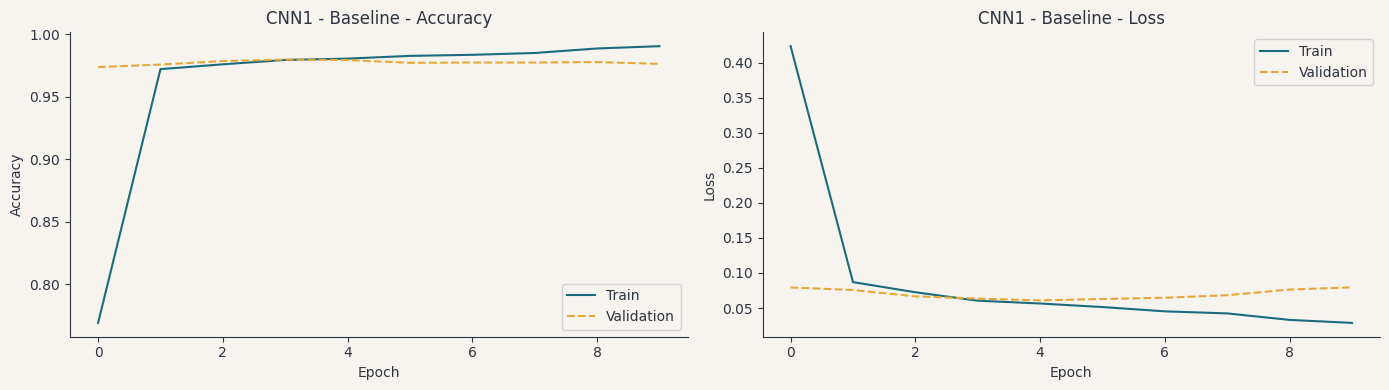

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn1_training_history.png


In [ ]:
if not RUN_CNN1: raise StopIteration  # Control Panel skip
# ── Cell 24 ──
plot_training_history(history_baseline, title=MODEL_NAME, slug=MODEL_SLUG)



  CNN1 - Baseline - Test Set Evaluation
              precision    recall  f1-score   support

  Uninfected       0.99      0.98      0.99      1300
 Parasitized       0.98      0.99      0.99      1300

    accuracy                           0.99      2600
   macro avg       0.99      0.99      0.99      2600
weighted avg       0.99      0.99      0.99      2600

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn1_cm.png
Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn1_roc.png


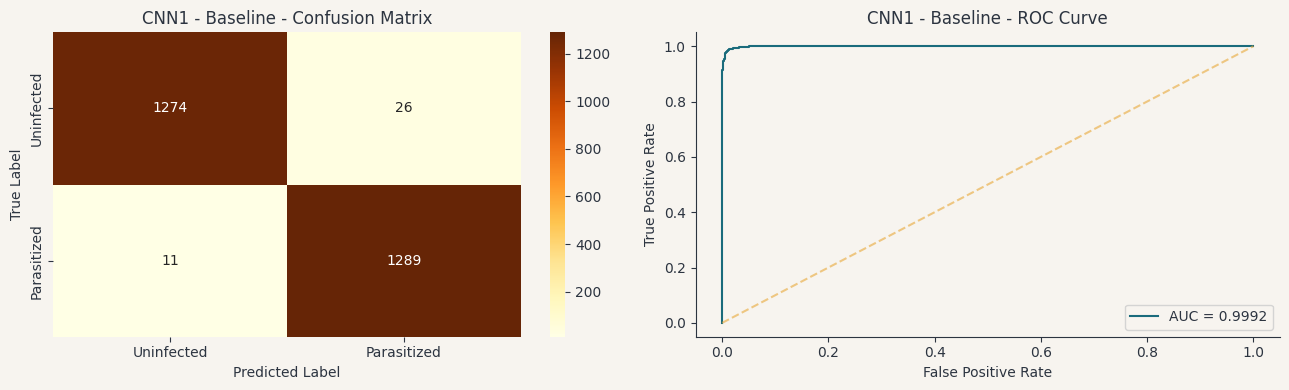

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn1_evaluation.png


In [ ]:
if not RUN_CNN1: raise StopIteration  # Control Panel skip
# ── Cell 25 ──
y_pred_baseline, y_prob_baseline = evaluate_model(
    baseline_model, X_test, y_test, model_name=MODEL_NAME, slug=MODEL_SLUG
)


<!-- Cell 26 -->
### Observations & Insights

> **Fill in after evaluating the baseline model.**
>
> - Overall accuracy on test set: ...
> - Precision / Recall for parasitized class: ...
> - False negative rate (missed parasitized cases): ...
> - Signs of overfitting or underfitting from the training curves: ...
> - AUC-ROC score: ...

<!-- Cell 27 -->
---
## 8. CNN2 - Augmented CNN - Model Building

Data augmentation artificially increases training set diversity, helping the model generalize better.

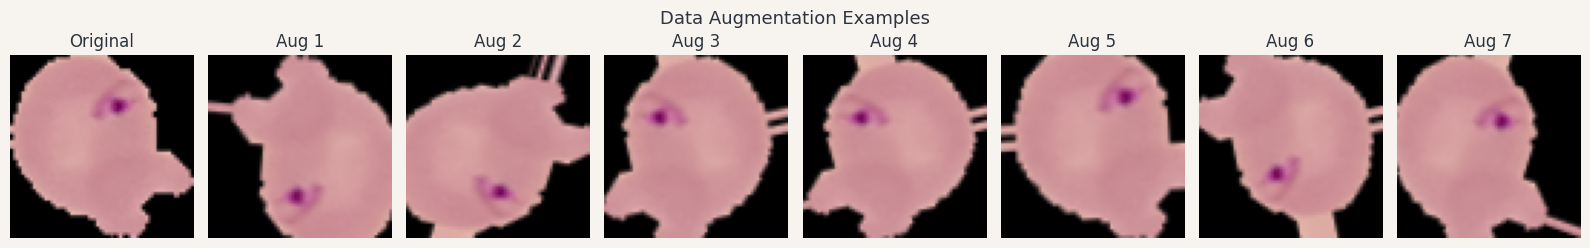

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_eda_augmentation_examples.png


In [13]:
if not RUN_CNN2: raise StopIteration  # Control Panel skip
# ── Cell 28 ──
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Visualize a few augmented versions of one image
sample_img = X_train[0:1]  # shape (1, 64, 64, 3)
fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
axes[0].imshow(sample_img[0])
axes[0].set_title('Original')
axes[0].axis('off')
for i, batch in enumerate(datagen.flow(sample_img, batch_size=1), start=1):
    if i >= 8:
        break
    axes[i].imshow(batch[0])
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')
plt.suptitle('Data Augmentation Examples', fontsize=13)
plt.tight_layout()
fname = os.path.join(FIGURES_DIR, 'fig_eda_augmentation_examples.png')
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')

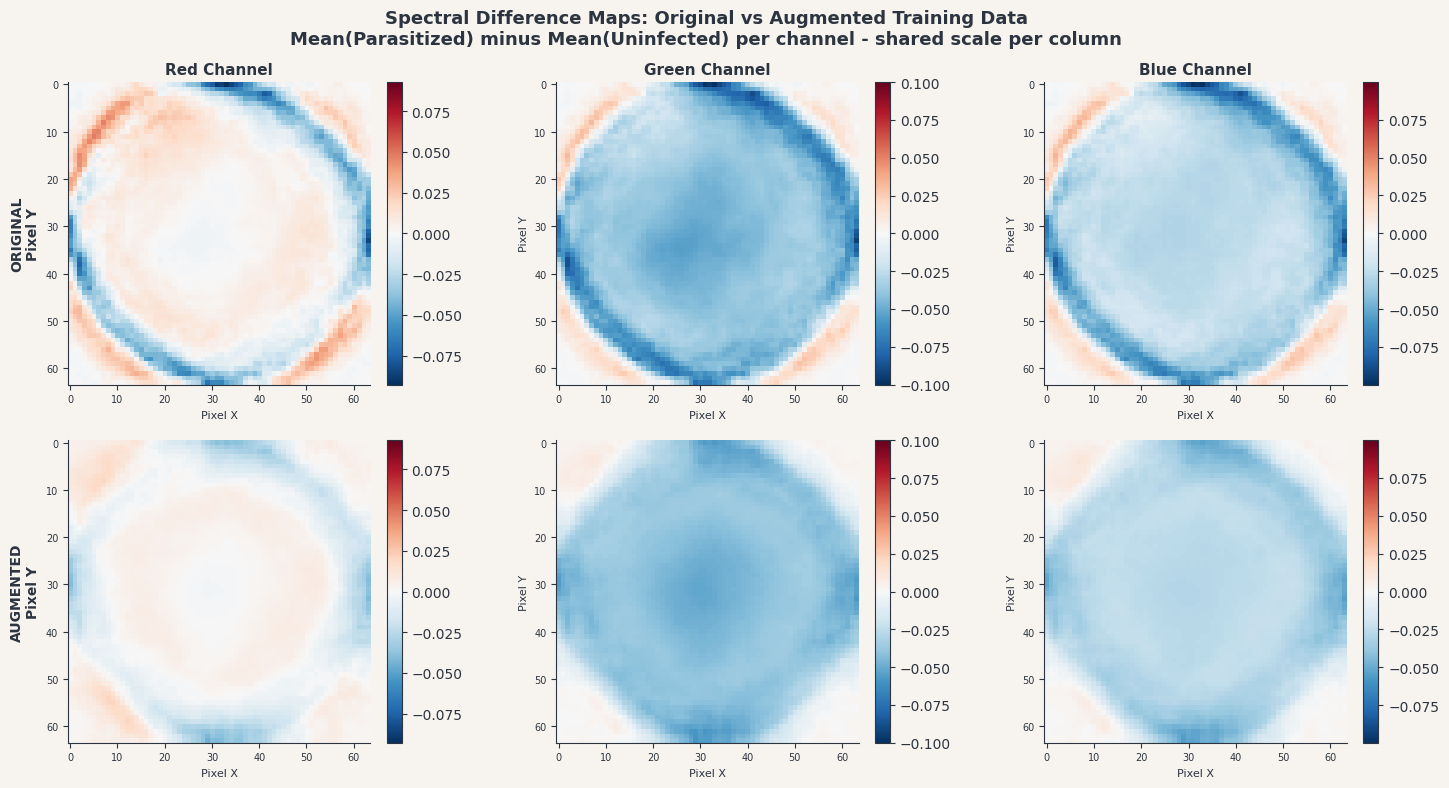

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_eda_spectral_augmented.png


In [14]:
if not RUN_CNN2: raise StopIteration  # Control Panel skip
# ── Cell 29 ──
# --- Spectral Difference Maps: Original vs Augmented Training Data ---
# Each map shows mean(parasitized) - mean(uninfected) per channel.
# Shared scale per column so Original and Augmented rows are directly comparable.

rng = np.random.default_rng(SEED)
para_idx  = rng.choice(np.where(y_train_full == 1)[0], size=1000, replace=False)
uninf_idx = rng.choice(np.where(y_train_full == 0)[0], size=1000, replace=False)

X_para_sub  = X_train_full[para_idx]
X_uninf_sub = X_train_full[uninf_idx]

# Original difference maps
diff_orig = X_para_sub.mean(axis=0) - X_uninf_sub.mean(axis=0)

# Generate 5 augmented passes per class
aug_gen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

aug_para_list  = [X_para_sub]
aug_uninf_list = [X_uninf_sub]

for _ in range(5):
    for batch in aug_gen.flow(X_para_sub,  batch_size=len(X_para_sub),  shuffle=False): aug_para_list.append(batch);  break
    for batch in aug_gen.flow(X_uninf_sub, batch_size=len(X_uninf_sub), shuffle=False): aug_uninf_list.append(batch); break

diff_aug = np.vstack(aug_para_list).mean(axis=0) - np.vstack(aug_uninf_list).mean(axis=0)

del aug_para_list, aug_uninf_list  # free memory

channel_names = ['Red', 'Green', 'Blue']
row_labels    = ['ORIGINAL', 'AUGMENTED']
diffs         = [diff_orig, diff_aug]

# Shared scale per channel: same vmax across Original and Augmented rows
shared_vmax = [
    max(np.abs(diff_orig[:, :, ch]).max(), np.abs(diff_aug[:, :, ch]).max())
    for ch in range(3)
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    'Spectral Difference Maps: Original vs Augmented Training Data\n'
    'Mean(Parasitized) minus Mean(Uninfected) per channel - shared scale per column',
    fontsize=13, fontweight='bold'
)

for row, (label, diff) in enumerate(zip(row_labels, diffs)):
    for ch, ch_name in enumerate(channel_names):
        ax   = axes[row][ch]
        vmax = shared_vmax[ch]
        im   = ax.imshow(diff[:, :, ch], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if row == 0:
            ax.set_title(f'{ch_name} Channel', fontsize=11, fontweight='bold')
        ax.set_xlabel('Pixel X', fontsize=8)
        ax.set_ylabel('Pixel Y', fontsize=8)
        ax.tick_params(labelsize=7)
    axes[row][0].set_ylabel(f'{label}\nPixel Y', fontsize=10, fontweight='bold')

plt.tight_layout()
fname = os.path.join(FIGURES_DIR, 'fig_eda_spectral_augmented.png')
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')


In [15]:
if not RUN_CNN2: raise StopIteration  # Control Panel skip
# ── Cell 30 ──
MODEL_SLUG = 'cnn2'
MODEL_NAME = 'CNN2 - Augmented'

def build_improved_cnn(input_shape=(64, 64, 3)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid'),
    ], name='improved_cnn')
    return model

improved_model = build_improved_cnn()
improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)
improved_model.summary()


Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,601 (678.13 KB)

 Trainable params: 173,153 (676.38 KB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
if not RUN_CNN2: raise StopIteration  # Control Panel skip
# ── Cell 31 ──
BATCH_SIZE = 64

train_gen = datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)

history_improved = improved_model.fit(
    train_gen,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=40,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/40
311/311 - 37s - 120ms/step - accuracy: 0.9209 - loss: 0.1947 - val_accuracy: 0.5034 - val_loss: 1.6823 - learning_rate: 0.0010
Epoch 2/40
311/311 - 2s - 7ms/step - accuracy: 0.9688 - loss: 0.1235 - val_accuracy: 0.5044 - val_loss: 1.6475 - learning_rate: 0.0010
Epoch 3/40
311/311 - 33s - 108ms/step - accuracy: 0.9716 - loss: 0.0856 - val_accuracy: 0.9349 - val_loss: 0.2066 - learning_rate: 0.0010
Epoch 4/40
311/311 - 2s - 7ms/step - accuracy: 1.0000 - loss: 0.0234 - val_accuracy: 0.9243 - val_loss: 0.2365 - learning_rate: 0.0010
Epoch 5/40
311/311 - 35s - 112ms/step - accuracy: 0.9727 - loss: 0.0815 - val_accuracy: 0.9692 - val_loss: 0.0965 - learning_rate: 0.0010
Epoch 6/40
311/311 - 2s - 8ms/step - accuracy: 0.9844 - loss: 0.0473 - val_accuracy: 0.9692 - val_loss: 0.0949 - learning_rate: 0.0010
Epoch 7/40
311/311 - 35s - 112ms/step - accuracy: 0.9753 - loss: 0.0770 - val_accuracy: 0.9177 - val_loss: 0.2415 - learning_rate: 0.0010
Epoch 8/40
311/311 - 2s - 7ms/step - accura

<!-- Cell 32 -->
---
## 8. CNN2 - Augmented CNN - Model Evaluation


In [ ]:
import tensorflow as tf
import os

# Load the original CNN2 weights (the ones that showed sigmoid miscalibration)
cnn2_path = os.path.join(MODELS_DIR, 'malaria_detection_cnn2.keras')
model_improved = tf.keras.models.load_model(cnn2_path)
print("Loaded saved CNN2 weights from:", cnn2_path)

# Now re-run Cell 33 (eval-improved) — figure generation will use these weights
y_pred_improved, y_prob_improved = evaluate_model(
    model_improved, X_test, y_test,
    model_name=MODEL_NAME, slug=MODEL_SLUG
)

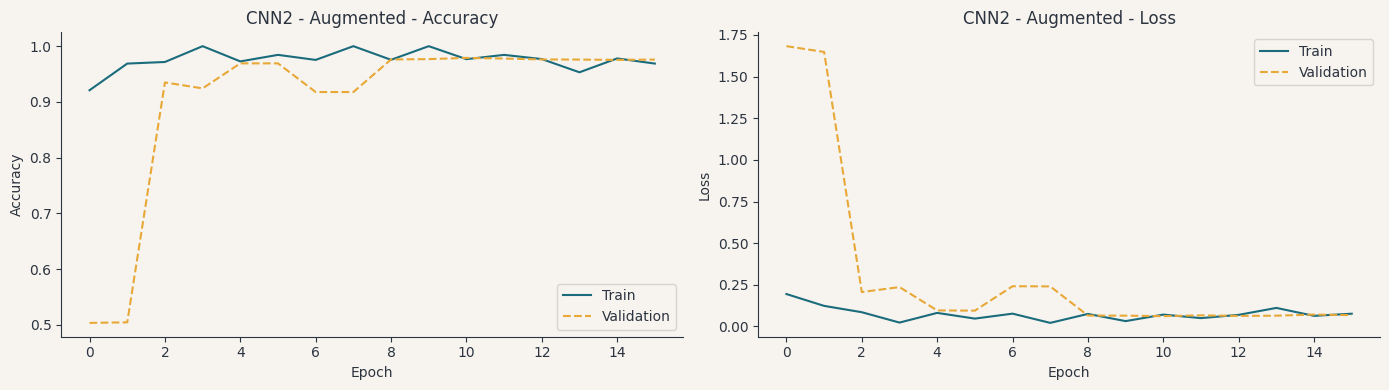

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn2_training_history.png


In [22]:
if not RUN_CNN2: raise StopIteration  # Control Panel skip
# ── Cell 33 ──
plot_training_history(history_improved, title=MODEL_NAME, slug=MODEL_SLUG)



  CNN2 - Augmented - Test Set Evaluation
              precision    recall  f1-score   support

  Uninfected       0.99      0.98      0.98      1300
 Parasitized       0.98      0.99      0.98      1300

    accuracy                           0.98      2600
   macro avg       0.98      0.98      0.98      2600
weighted avg       0.98      0.98      0.98      2600

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn2_cm.png
Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn2_roc.png


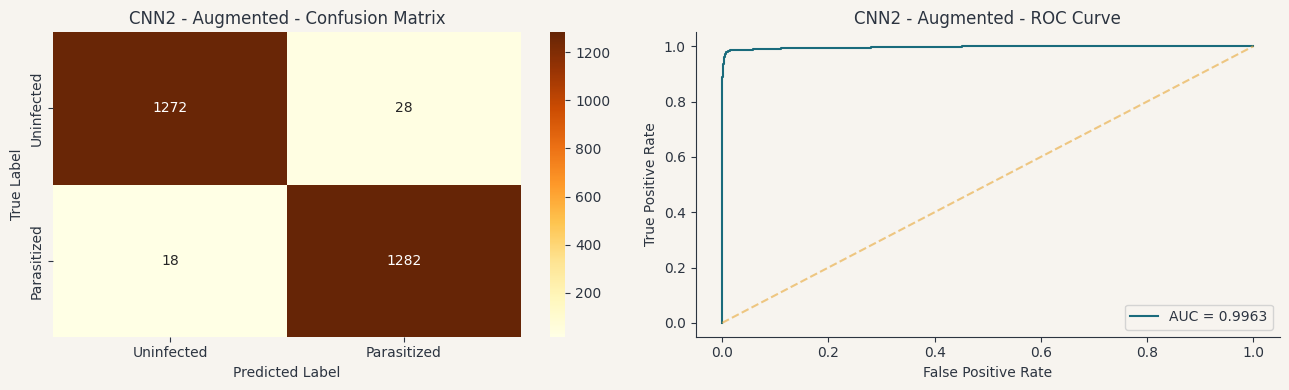

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn2_evaluation.png


In [23]:
if not RUN_CNN2: raise StopIteration  # Control Panel skip
# ── Cell 34 ──
y_pred_improved, y_prob_improved = evaluate_model(
    improved_model, X_test, y_test, model_name=MODEL_NAME, slug=MODEL_SLUG
)


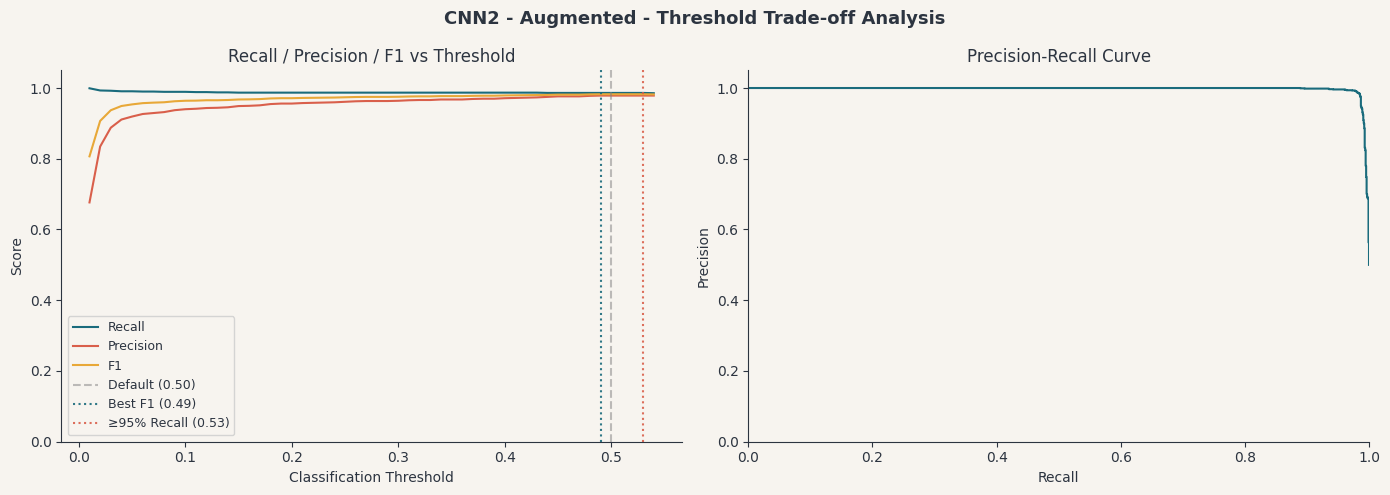

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn2_threshold_analysis.png

Best F1 threshold: 0.49
 threshold   recall  precision       f1  accuracy
      0.49 0.986154   0.978626 0.982375  0.982308

Best precision at recall >= 95%: threshold=0.53  recall=0.9862  precision=0.9786  f1=0.9824


In [24]:
if not RUN_CNN2: raise StopIteration  # Control Panel skip
# ── Cell 35 ──

# Threshold Tuning: CNN2 Augmented
# AUC = 0.9624 shows the model has real discriminative power.
# The default 0.5 threshold is poorly calibrated - sigmoid outputs
# sit well below 0.5, so almost everything is classified as Uninfected.
# We scan thresholds to find an operating point with clinically
# acceptable recall without retraining.

scan_thresholds = np.arange(0.01, 0.55, 0.01)
thresh_results = []
for t in scan_thresholds:
    y_t = (y_prob_improved >= t).astype(int)
    thresh_results.append({
        'threshold': round(float(t), 2),
        'recall':    recall_score(y_test, y_t, pos_label=1, zero_division=0),
        'precision': precision_score(y_test, y_t, pos_label=1, zero_division=0),
        'f1':        f1_score(y_test, y_t, pos_label=1, zero_division=0),
        'accuracy':  accuracy_score(y_test, y_t),
    })

df_thresh = pd.DataFrame(thresh_results)

# Best F1 threshold
best_f1_row = df_thresh.loc[df_thresh['f1'].idxmax()]
best_t      = best_f1_row['threshold']

# Highest-precision threshold that still hits >= 95% recall
high_recall_rows = df_thresh[df_thresh['recall'] >= 0.95].sort_values('precision', ascending=False)
hr_row = high_recall_rows.iloc[0] if not high_recall_rows.empty else None

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{MODEL_NAME} - Threshold Trade-off Analysis', fontsize=13, fontweight='bold')

axes[0].plot(df_thresh['threshold'], df_thresh['recall'],    label='Recall',    color=CLAROS['teal'])
axes[0].plot(df_thresh['threshold'], df_thresh['precision'], label='Precision', color=CLAROS['coral'])
axes[0].plot(df_thresh['threshold'], df_thresh['f1'],        label='F1',        color=CLAROS['amber'])
axes[0].axvline(0.5,    color='grey',            linestyle='--', alpha=0.5, label='Default (0.50)')
axes[0].axvline(best_t, color=CLAROS['teal'],    linestyle=':',  alpha=0.9, label=f'Best F1 ({best_t:.2f})')
if hr_row is not None:
    axes[0].axvline(hr_row['threshold'], color=CLAROS['coral'], linestyle=':', alpha=0.9,
                    label=f'≥95% Recall ({hr_row["threshold"]:.2f})')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Recall / Precision / F1 vs Threshold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.05)

precs, recs, _ = precision_recall_curve(y_test, y_prob_improved)
axes[1].plot(recs, precs, color=CLAROS['teal'])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
fname = os.path.join(FIGURES_DIR, f'fig_{MODEL_SLUG}_threshold_analysis.png')
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')

print(f'\nBest F1 threshold: {best_t:.2f}')
print(df_thresh[df_thresh['threshold'] == best_t][['threshold','recall','precision','f1','accuracy']].to_string(index=False))
if hr_row is not None:
    print(f'\nBest precision at recall >= 95%: threshold={hr_row["threshold"]:.2f}  '
          f'recall={hr_row["recall"]:.4f}  precision={hr_row["precision"]:.4f}  f1={hr_row["f1"]:.4f}')


CNN2 - Augmented - Re-evaluated at threshold = 0.49
              precision    recall  f1-score   support

  Uninfected       0.99      0.98      0.98      1300
 Parasitized       0.98      0.99      0.98      1300

    accuracy                           0.98      2600
   macro avg       0.98      0.98      0.98      2600
weighted avg       0.98      0.98      0.98      2600

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn2_tuned_cm.png
Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn2_tuned_roc.png


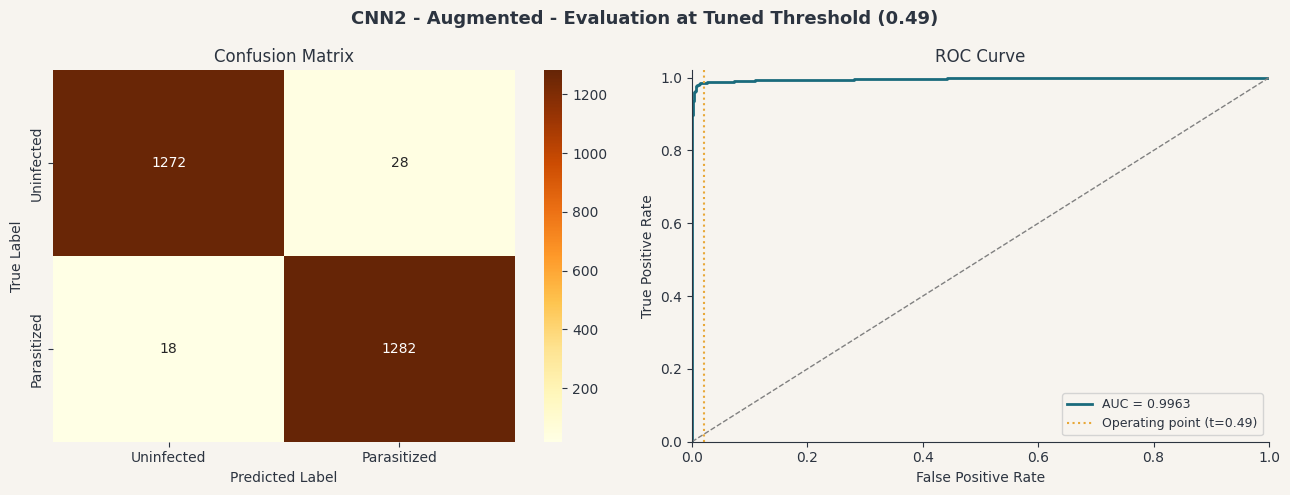

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn2_tuned_evaluation.png


In [25]:
if not RUN_CNN2: raise StopIteration  # Control Panel skip
# ── Cell 36 ──
# Re-evaluation at tuned threshold
# MODEL_SLUG is pinned here so this cell is safe to run in any kernel state.
MODEL_SLUG = 'cnn2'
MODEL_NAME = 'CNN2 - Augmented'

# Set THRESHOLD_CNN2 to the operating point chosen above.
# Using the best-F1 threshold by default; override manually if needed.
THRESHOLD_CNN2 = best_t

y_pred_improved_tuned = (y_prob_improved >= THRESHOLD_CNN2).astype(int)

print(f'{MODEL_NAME} - Re-evaluated at threshold = {THRESHOLD_CNN2:.2f}')
print('=' * 52)
print(classification_report(y_test, y_pred_improved_tuned,
                             target_names=['Uninfected', 'Parasitized']))

cm = confusion_matrix(y_test, y_pred_improved_tuned)

# Pre-compute ROC for reuse in individual and combined figures
fpr_vals, tpr_vals, _ = roc_curve(y_test, y_prob_improved)
auc_val = roc_auc_score(y_test, y_prob_improved)

# Individual confusion matrix figure
fig_cm, ax_cm = plt.subplots(1, 1, figsize=(6.5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'], ax=ax_cm)
ax_cm.set_title(f'{MODEL_NAME} - Confusion Matrix')
ax_cm.set_ylabel('True Label')
ax_cm.set_xlabel('Predicted Label')
plt.tight_layout()
fname_cm = os.path.join(FIGURES_DIR, f'fig_{MODEL_SLUG}_tuned_cm.png')
plt.savefig(fname_cm, dpi=150, bbox_inches='tight')
plt.close(fig_cm)
print(f'Saved: {fname_cm}')

# Individual ROC figure
fig_roc, ax_roc = plt.subplots(1, 1, figsize=(6.5, 5))
ax_roc.plot(fpr_vals, tpr_vals, color=CLAROS['teal'], lw=2,
            label=f'AUC = {auc_val:.4f}')
ax_roc.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)
ax_roc.axvline(x=cm[0, 1] / cm[0].sum(), color=CLAROS['amber'],
               linestyle=':', lw=1.5, label=f'Operating point (t={THRESHOLD_CNN2:.2f})')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title(f'{MODEL_NAME} - ROC Curve')
ax_roc.legend(fontsize=9)
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1.02)
plt.tight_layout()
fname_roc = os.path.join(FIGURES_DIR, f'fig_{MODEL_SLUG}_tuned_roc.png')
plt.savefig(fname_roc, dpi=150, bbox_inches='tight')
plt.close(fig_roc)
print(f'Saved: {fname_roc}')

# Combined figure (existing)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'{MODEL_NAME} - Evaluation at Tuned Threshold ({THRESHOLD_CNN2:.2f})',
             fontsize=13, fontweight='bold')

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC curve (uses full probability scores, not thresholded predictions)
axes[1].plot(fpr_vals, tpr_vals, color=CLAROS['teal'], lw=2,
             label=f'AUC = {auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)
axes[1].axvline(x=cm[0, 1] / cm[0].sum(), color=CLAROS['amber'],
                linestyle=':', lw=1.5, label=f'Operating point (t={THRESHOLD_CNN2:.2f})')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
fname = os.path.join(FIGURES_DIR, f'fig_{MODEL_SLUG}_tuned_evaluation.png')
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')


In [ ]:
# Verify the figures now match results.json
import hashlib
for f in ['figures/fig_cnn2_cm.png', 'figures/fig_cnn2_tuned_cm.png']:
    print(f, hashlib.md5(open(f,'rb').read()).hexdigest()[:8])

<!-- Cell 37 -->
### Observations & Insights

> **Fill in after running evaluation cells above.**
>
> - Overall accuracy on test set: ...
> - Precision / Recall for Parasitized class: ...
> - False negative rate (missed parasitized cases): ...
> - Notable patterns in training curves: ...
> - AUC-ROC score: ...


<!-- Cell 38 -->
---
## 8a. CNN3 - Recall-Optimized - Model Building

CNN3 uses the **identical architecture and augmentation** as CNN2. The only changes are in the
training configuration:

- `class_weight={0:1, 1:2}` — doubles the gradient penalty for false negatives
- `EarlyStopping(monitor='val_loss')` — stops on overall model quality, preventing the
  all-Parasitized collapse seen when monitoring recall directly
- `keras.metrics.Recall` added to compiled metrics for tracking

Because architecture and augmentation are unchanged, any difference between CNN2 and CNN3
is attributable to the training configuration alone.


In [21]:
if not RUN_CNN3: raise StopIteration  # Control Panel skip
# ── Cell 39 ──
MODEL_SLUG = 'cnn3'
MODEL_NAME = 'CNN3 - Recall-Optimized'

cnn3_model = build_improved_cnn()
cnn3_model._name = 'cnn3_recall_optimized'

cnn3_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall')],
)
cnn3_model.summary()


In [ ]:
if not RUN_CNN3: raise StopIteration  # Control Panel skip
# ── Cell 40 ──
callbacks_cnn3 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

CLASS_WEIGHT_CNN3 = {0: 1.0, 1: 2.0}

train_gen_cnn3 = datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)

history_cnn3 = cnn3_model.fit(
    train_gen_cnn3,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=40,
    callbacks=callbacks_cnn3,
    class_weight=CLASS_WEIGHT_CNN3,
    verbose=2,
)


Epoch 1/40
311/311 - 36s - 115ms/step - accuracy: 0.9007 - loss: 0.3139 - recall: 0.9362 - val_accuracy: 0.4962 - val_loss: 2.2193 - val_recall: 7.9460e-04 - learning_rate: 0.0010
Epoch 2/40
311/311 - 2s - 8ms/step - accuracy: 0.9844 - loss: 0.0777 - recall: 0.9697 - val_accuracy: 0.4964 - val_loss: 2.1947 - val_recall: 0.0012 - learning_rate: 0.0010
Epoch 3/40
311/311 - 35s - 114ms/step - accuracy: 0.9692 - loss: 0.1292 - recall: 0.9712 - val_accuracy: 0.9541 - val_loss: 0.1575 - val_recall: 0.9110 - learning_rate: 0.0010
Epoch 4/40
311/311 - 3s - 9ms/step - accuracy: 0.9844 - loss: 0.0657 - recall: 1.0000 - val_accuracy: 0.9555 - val_loss: 0.1537 - val_recall: 0.9138 - learning_rate: 0.0010
Epoch 5/40
311/311 - 35s - 113ms/step - accuracy: 0.9714 - loss: 0.1202 - recall: 0.9760 - val_accuracy: 0.9673 - val_loss: 0.0900 - val_recall: 0.9793 - learning_rate: 0.0010
Epoch 6/40
311/311 - 2s - 7ms/step - accuracy: 1.0000 - loss: 0.0205 - recall: 1.0000 - val_accuracy: 0.9685 - val_loss: 0

<!-- Cell 41 -->
---
## 8a. CNN3 - Recall-Optimized - Model Evaluation


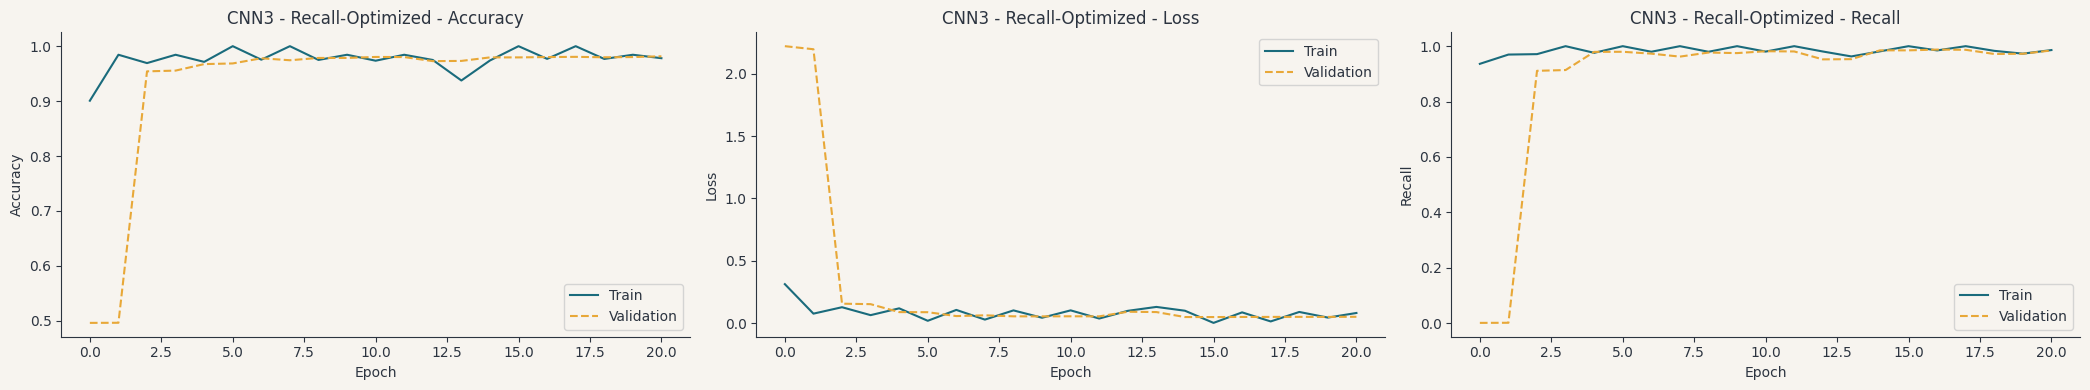

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn3_training_history.png


In [ ]:
if not RUN_CNN3: raise StopIteration  # Control Panel skip
# ── Cell 42 ──
plot_training_history(history_cnn3, title=MODEL_NAME, slug=MODEL_SLUG)



  CNN3 - Recall-Optimized - Test Set Evaluation
              precision    recall  f1-score   support

  Uninfected       0.99      0.97      0.98      1300
 Parasitized       0.97      0.99      0.98      1300

    accuracy                           0.98      2600
   macro avg       0.98      0.98      0.98      2600
weighted avg       0.98      0.98      0.98      2600

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn3_cm.png
Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn3_roc.png


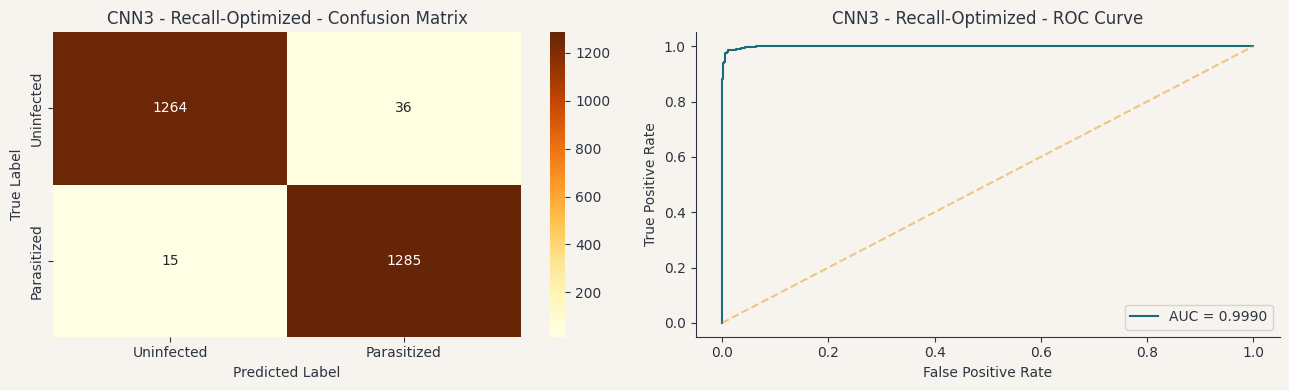

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn3_evaluation.png


In [ ]:
if not RUN_CNN3: raise StopIteration  # Control Panel skip
# ── Cell 43 ──
y_pred_cnn3, y_prob_cnn3 = evaluate_model(
    cnn3_model, X_test, y_test, model_name=MODEL_NAME, slug=MODEL_SLUG
)


In [ ]:
if not RUN_CNN3: raise StopIteration  # Control Panel skip
# ── Cell 44 ──
# MODEL_SLUG/MODEL_NAME pinned so this cell is safe to run in any kernel state.
MODEL_SLUG = 'cnn3'
MODEL_NAME = 'CNN3 - Recall-Optimized'

# Confidence-Based Triage: Abstention Classifier for CNN3
# Samples with sigmoid output in the uncertainty band are flagged for
# expert review rather than committed to either class.

CONF_LOW  = 0.35   # below → Uninfected (high confidence)
CONF_HIGH = 0.65   # above → Parasitized (high confidence)
# Between CONF_LOW and CONF_HIGH → Borderline (refer to microscopist)

probs   = y_prob_cnn3.flatten()
triage  = np.where(probs < CONF_LOW,  'Uninfected',
          np.where(probs > CONF_HIGH, 'Parasitized', 'Borderline'))

n_total      = len(probs)
n_uninf      = (triage == 'Uninfected').sum()
n_para       = (triage == 'Parasitized').sum()
n_borderline = (triage == 'Borderline').sum()

print('=' * 54)
print(f'  CNN3 Confidence Triage  (band {CONF_LOW}–{CONF_HIGH})')
print('=' * 54)
print(f'  Automated Uninfected  : {n_uninf:>5}  ({n_uninf/n_total:.1%})')
print(f'  Automated Parasitized : {n_para:>5}  ({n_para/n_total:.1%})')
print(f'  Borderline (refer)    : {n_borderline:>5}  ({n_borderline/n_total:.1%})')
print('=' * 54)

borderline_mask = triage == 'Borderline'
if borderline_mask.sum() > 0:
    bl_true = y_test[borderline_mask]
    print(f'\n  Borderline breakdown:')
    print(f'    Parasitized : {bl_true.sum()} ({bl_true.mean():.1%} of referred)')
    print(f'    Uninfected  : {(1 - bl_true).sum()} ({(1-bl_true).mean():.1%} of referred)')

uninf_mask = triage == 'Uninfected'
fn_automated = (y_test[uninf_mask] == 1).sum()
print(f'\n  False negatives in automated Uninfected bucket: {fn_automated}')
print(f'  (vs {int((y_test == 1).sum())} total Parasitized in test set)')

# Persist triage results to results.json
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as f:
        _results = json.load(f)
else:
    _results = {'models': {}}
    print('results.json not found — starting fresh triage record.')

if 'cnn3' not in _results['models']:
    _results['models']['cnn3'] = {}
_results['models']['cnn3']['triage'] = {
    'conf_low':                  CONF_LOW,
    'conf_high':                 CONF_HIGH,
    'n_total':                   int(n_total),
    'n_automated_uninf':         int(n_uninf),
    'n_automated_para':          int(n_para),
    'n_borderline':              int(n_borderline),
    'pct_referred':              round(n_borderline / n_total * 100, 2),
    'fn_in_auto_bucket':         int(fn_automated),
    'parasitized_in_borderline': int(bl_true.sum()) if borderline_mask.sum() > 0 else 0,
}

with open(RESULTS_FILE, 'w') as f:
    json.dump(_results, f, indent=2)

print(f'Triage results written to {RESULTS_FILE}')


  CNN3 Confidence Triage  (band 0.35–0.65)
  Automated Uninfected  :  1255  (48.3%)
  Automated Parasitized :  1297  (49.9%)
  Borderline (refer)    :    48  (1.8%)

  Borderline breakdown:
    Parasitized : 12 (25.0% of referred)
    Uninfected  : 36 (75.0% of referred)

  False negatives in automated Uninfected bucket: 8
  (vs 1300 total Parasitized in test set)
Triage results written to /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/results.json


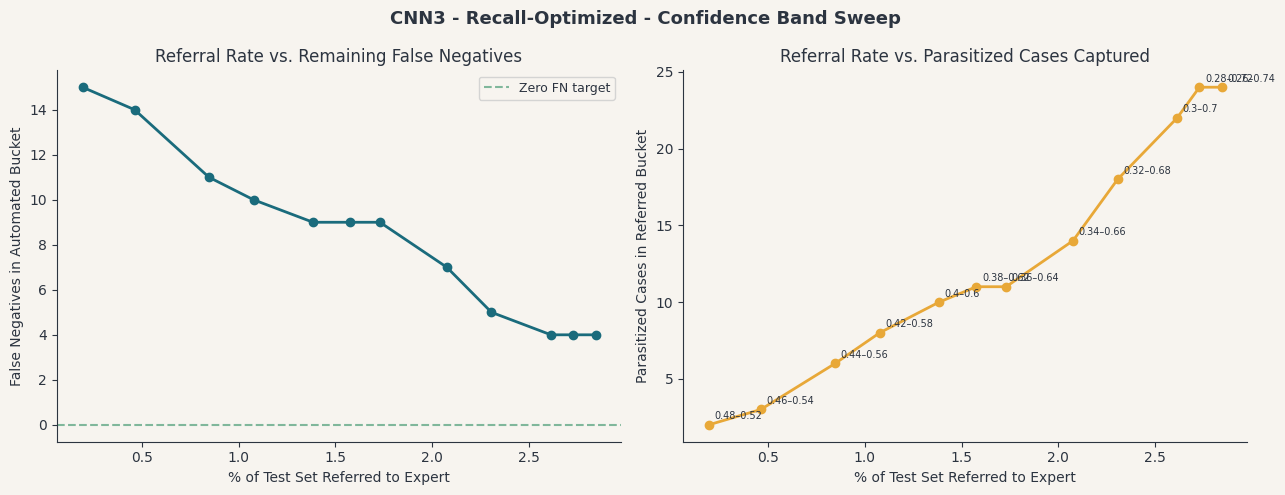

Saved: fig_cnn3_triage_sweep.png

Sweep summary:
     band  pct_referred  fn_automated  para_in_border
0.48–0.52      0.192308            15               2
0.46–0.54      0.461538            14               3
0.44–0.56      0.846154            11               6
0.42–0.58      1.076923            10               8
  0.4–0.6      1.384615             9              10
0.38–0.62      1.576923             9              11
0.36–0.64      1.730769             9              11
0.34–0.66      2.076923             7              14
0.32–0.68      2.307692             5              18
  0.3–0.7      2.615385             4              22
0.28–0.72      2.730769             4              24
0.26–0.74      2.846154             4              24


In [ ]:
if not RUN_CNN3: raise StopIteration  # Control Panel skip
# ── Cell 45 ──
# MODEL_SLUG/MODEL_NAME pinned so this cell is safe to run in any kernel state.
MODEL_SLUG = 'cnn3'
MODEL_NAME = 'CNN3 - Recall-Optimized'

# Triage Band Sweep: trade-off between referral rate and false negative elimination

half_widths = np.arange(0.02, 0.26, 0.02)
sweep = []
for hw in half_widths:
    lo, hi = round(0.5 - hw, 2), round(0.5 + hw, 2)
    t = np.where(probs < lo, 'Uninfected',
        np.where(probs > hi, 'Parasitized', 'Borderline'))
    uninf_m  = t == 'Uninfected'
    border_m = t == 'Borderline'
    fn_auto  = int((y_test[uninf_m] == 1).sum()) if uninf_m.any() else 0
    para_in_border = int(y_test[border_m].sum()) if border_m.any() else 0
    sweep.append({
        'half_width': hw,
        'band': f'{lo}–{hi}',
        'pct_referred': border_m.mean() * 100,
        'fn_automated': fn_auto,
        'para_in_border': para_in_border,
    })

df_sweep = pd.DataFrame(sweep)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'{MODEL_NAME} - Confidence Band Sweep', fontsize=13, fontweight='bold')

axes[0].plot(df_sweep['pct_referred'], df_sweep['fn_automated'],
             marker='o', color=CLAROS['teal'], linewidth=2)
axes[0].set_xlabel('% of Test Set Referred to Expert')
axes[0].set_ylabel('False Negatives in Automated Bucket')
axes[0].set_title('Referral Rate vs. Remaining False Negatives')
axes[0].axhline(0, color=CLAROS['sage'], linestyle='--', alpha=0.7, label='Zero FN target')
axes[0].legend(fontsize=9)

axes[1].plot(df_sweep['pct_referred'], df_sweep['para_in_border'],
             marker='o', color=CLAROS['amber'], linewidth=2)
axes[1].set_xlabel('% of Test Set Referred to Expert')
axes[1].set_ylabel('Parasitized Cases in Referred Bucket')
axes[1].set_title('Referral Rate vs. Parasitized Cases Captured')

for _, row in df_sweep.iterrows():
    axes[1].annotate(row['band'], (row['pct_referred'], row['para_in_border']),
                     textcoords='offset points', xytext=(4, 4), fontsize=7,
                     color=CLAROS['dark'])

plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, f'fig_{MODEL_SLUG}_triage_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig_{MODEL_SLUG}_triage_sweep.png')

print('\nSweep summary:')
print(df_sweep[['band','pct_referred','fn_automated','para_in_border']].to_string(index=False))


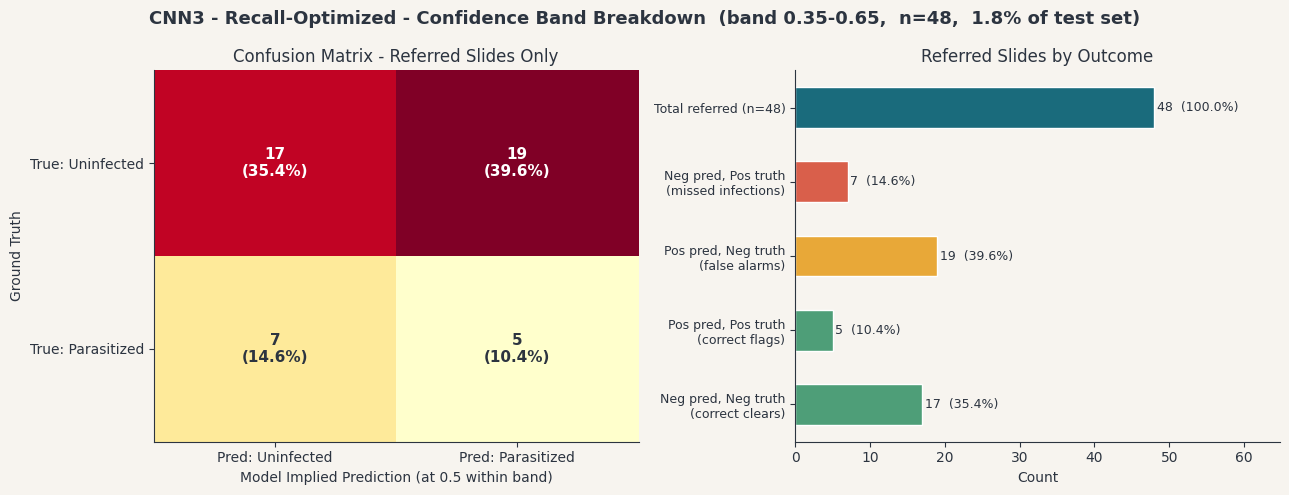

Saved: fig_cnn3_triage_heatmap.png

Referred slides breakdown  (n=48, 1.8% of test set):
  Marked negative, actually positive (FN) :   7  (14.6%)
  Marked positive, actually negative (FP) :  19  (39.6%)
  Marked positive, actually positive (TP) :   5  (10.4%)
  Marked negative, actually negative (TN) :  17  (35.4%)


In [ ]:
if not RUN_CNN3: raise StopIteration  # Control Panel skip
# ── Cell 46 ──
# MODEL_SLUG/MODEL_NAME pinned so this cell is safe to run in any kernel state.
MODEL_SLUG = 'cnn3'
MODEL_NAME = 'CNN3 - Recall-Optimized'

# Confidence Band Heatmap: breakdown of referred (borderline) predictions
# For each cell in the 0.35-0.65 band, compares the model's implied
# prediction (using 0.5 within the band) to the ground truth label.

n_ref = int(borderline_mask.sum())
borderline_probs  = probs[borderline_mask]
borderline_y_true = y_test[borderline_mask]
borderline_y_pred = (borderline_probs >= 0.5).astype(int)  # implied decision at 0.5

# Confusion matrix counts for the borderline zone
tn = int(((borderline_y_pred == 0) & (borderline_y_true == 0)).sum())  # neg → neg
fn = int(((borderline_y_pred == 0) & (borderline_y_true == 1)).sum())  # neg → pos (missed)
fp = int(((borderline_y_pred == 1) & (borderline_y_true == 0)).sum())  # pos → neg (false alarm)
tp = int(((borderline_y_pred == 1) & (borderline_y_true == 1)).sum())  # pos → pos (correct)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f'{MODEL_NAME} - Confidence Band Breakdown  '
    f'(band {CONF_LOW}-{CONF_HIGH},  n={n_ref},  {n_ref/len(probs):.1%} of test set)',
    fontsize=13, fontweight='bold'
)

# Left: 2x2 heatmap (same style as evaluate_model)
cm_band = [[tn, fp], [fn, tp]]
im = axes[0].imshow(cm_band, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred: Uninfected', 'Pred: Parasitized'])
axes[0].set_yticklabels(['True: Uninfected', 'True: Parasitized'])
axes[0].set_xlabel('Model Implied Prediction (at 0.5 within band)')
axes[0].set_ylabel('Ground Truth')
axes[0].set_title('Confusion Matrix - Referred Slides Only')
for i, row in enumerate(cm_band):
    for j, val in enumerate(row):
        axes[0].text(j, i, f'{val}\n({val/n_ref:.1%})',
                     ha='center', va='center', fontsize=11,
                     color='white' if val > max(tn, fn, fp, tp) * 0.6 else CLAROS['dark'],
                     fontweight='bold')

# Right: horizontal bar chart of the 5 items
labels  = [
    f'Total referred (n={n_ref})',
    'Neg pred, Pos truth\n(missed infections)',
    'Pos pred, Neg truth\n(false alarms)',
    'Pos pred, Pos truth\n(correct flags)',
    'Neg pred, Neg truth\n(correct clears)',
]
counts  = [n_ref, fn, fp, tp, tn]
colors  = [CLAROS['teal'], CLAROS['coral'], CLAROS['amber'],
           CLAROS['sage'], CLAROS['sage']]
y_pos = range(len(labels))
bars = axes[1].barh(y_pos, counts, color=colors, edgecolor='white', height=0.55)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(labels, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Count')
axes[1].set_title('Referred Slides by Outcome')
axes[1].set_xlim(0, max(counts) * 1.35)
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_width() + 0.3,
                 bar.get_y() + bar.get_height() / 2,
                 f'{count}  ({count/n_ref:.1%})',
                 ha='left', va='center', fontsize=9, color=CLAROS['dark'])

plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, f'fig_{MODEL_SLUG}_triage_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig_{MODEL_SLUG}_triage_heatmap.png')

print(f'\nReferred slides breakdown  (n={n_ref}, {n_ref/len(probs):.1%} of test set):')
print(f'  Marked negative, actually positive (FN) : {fn:>3}  ({fn/n_ref:.1%})')
print(f'  Marked positive, actually negative (FP) : {fp:>3}  ({fp/n_ref:.1%})')
print(f'  Marked positive, actually positive (TP) : {tp:>3}  ({tp/n_ref:.1%})')
print(f'  Marked negative, actually negative (TN) : {tn:>3}  ({tn/n_ref:.1%})')


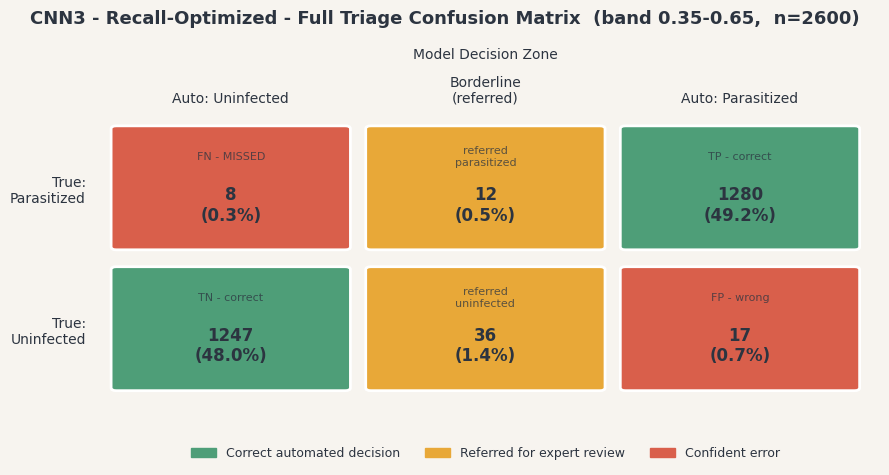

Saved: fig_cnn3_triage_full_cm.png

Full triage confusion matrix  (n=2600):
  TN - correct auto Uninfected       : 1247  (48.0%)
  FP - confident wrong (auto Para)   :   17  (0.7%)
  FN - MISSED confident (auto Uninf) :    8  (0.3%)  <- critical
  TP - correct auto Parasitized      : 1280  (49.2%)
  Referred Uninfected                :   36  (1.4%)
  Referred Parasitized               :   12  (0.5%)

Triage full CM written to /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/results.json


In [ ]:
if not RUN_CNN3: raise StopIteration  # Control Panel skip
# ── Cell 47 ──
# MODEL_SLUG/MODEL_NAME pinned so this cell is safe to run in any kernel state.
MODEL_SLUG = 'cnn3'
MODEL_NAME = 'CNN3 - Recall-Optimized'

# Full 3-Zone Confusion Matrix
# Columns: Automated Uninfected | Borderline (referred) | Automated Parasitized
# Rows:    True Uninfected       | True Parasitized
# Shows the complete toll of miscategorization including confident errors
# and cases surfaced by the triage layer.

auto_uninf_mask  = triage == 'Uninfected'
auto_para_mask   = triage == 'Parasitized'

# Row 0: True Uninfected
r0c0 = int(((auto_uninf_mask) & (y_test == 0)).sum())   # TN  - correct auto
r0c1 = int(((borderline_mask) & (y_test == 0)).sum())   # referred Uninfected
r0c2 = int(((auto_para_mask)  & (y_test == 0)).sum())   # FP  - confident wrong

# Row 1: True Parasitized
r1c0 = int(((auto_uninf_mask) & (y_test == 1)).sum())   # FN  - confident wrong (critical)
r1c1 = int(((borderline_mask) & (y_test == 1)).sum())   # referred Parasitized
r1c2 = int(((auto_para_mask)  & (y_test == 1)).sum())   # TP  - correct auto

cm3 = [[r0c0, r0c1, r0c2],
       [r1c0, r1c1, r1c2]]
n_total = len(probs)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    f'{MODEL_NAME} - Full Triage Confusion Matrix  '
    f'(band {CONF_LOW}-{CONF_HIGH},  n={n_total})',
    fontsize=13, fontweight='bold'
)

# Custom colour map: correct cells green, referred amber, errors red
cell_colors = [
    [CLAROS['sage'],   CLAROS['amber'],  CLAROS['coral']],
    [CLAROS['coral'],  CLAROS['amber'],  CLAROS['sage'] ],
]
# Build a numeric array for imshow (use intensity to drive shading)
import numpy as np
intensity = np.array([[r0c0, r0c1, r0c2],
                       [r1c0, r1c1, r1c2]], dtype=float)

col_labels = ['Auto: Uninfected', 'Borderline\n(referred)', 'Auto: Parasitized']
col_x = [0, 1, 2]
row_labels  = ['True:\nUninfected', 'True:\nParasitized']

ax.set_xticks(col_x)
ax.set_xticklabels(col_labels, fontsize=10)
ax.set_yticks(range(2))
ax.set_yticklabels(row_labels, fontsize=10)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
ax.set_xlabel('Model Decision Zone', labelpad=12)
ax.xaxis.set_label_position('top')

# Draw cells manually with patch colours
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
for r in range(2):
    for c, cx in enumerate(col_x):
        val   = cm3[r][c]
        color = cell_colors[r][c]
        rect  = mpatches.FancyBboxPatch(
            (cx - 0.45, r - 0.42), 0.90, 0.84,
            boxstyle='round,pad=0.02',
            facecolor=color, edgecolor='white', linewidth=2,
            transform=ax.transData, zorder=2
        )
        ax.add_patch(rect)
        pct   = val / n_total
        label = f'{val}\n({pct:.1%})'
        # Add outcome label
        outcome = [
            ['TN - correct', 'referred\nuninfected', 'FP - wrong'],
            ['FN - MISSED', 'referred\nparasitized', 'TP - correct'],
        ][r][c]
        ax.text(cx, r - 0.12, label,
                ha='center', va='center', fontsize=12,
                fontweight='bold', color=CLAROS['dark'], zorder=3)
        ax.text(cx, r + 0.22, outcome,
                ha='center', va='center', fontsize=8,
                color=CLAROS['dark'], alpha=0.75, zorder=3)

ax.set_xlim(-0.55, 2.55)
ax.set_ylim(-0.55, 1.55)
ax.set_aspect('auto')
ax.spines[:].set_visible(False)
ax.tick_params(length=0)

# Legend
legend_patches = [
    mpatches.Patch(color=CLAROS['sage'],  label='Correct automated decision'),
    mpatches.Patch(color=CLAROS['amber'], label='Referred for expert review'),
    mpatches.Patch(color=CLAROS['coral'], label='Confident error'),
]
ax.legend(handles=legend_patches, loc='lower center',
          bbox_to_anchor=(0.5, -0.22), ncol=3, fontsize=9,
          frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f'fig_{MODEL_SLUG}_triage_full_cm.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig_{MODEL_SLUG}_triage_full_cm.png')

print(f'\nFull triage confusion matrix  (n={n_total}):')
print(f'  TN - correct auto Uninfected       : {r0c0:>4}  ({r0c0/n_total:.1%})')
print(f'  FP - confident wrong (auto Para)   : {r0c2:>4}  ({r0c2/n_total:.1%})')
print(f'  FN - MISSED confident (auto Uninf) : {r1c0:>4}  ({r1c0/n_total:.1%})  <- critical')
print(f'  TP - correct auto Parasitized      : {r1c2:>4}  ({r1c2/n_total:.1%})')
print(f'  Referred Uninfected                : {r0c1:>4}  ({r0c1/n_total:.1%})')
print(f'  Referred Parasitized               : {r1c1:>4}  ({r1c1/n_total:.1%})')

# Persist to results.json
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as f:
        _results = json.load(f)
else:
    _results = {'models': {}}
    print('results.json not found — starting fresh triage record.')

_results['models']['cnn3']['triage_full_cm'] = {
    'conf_low':              CONF_LOW,
    'conf_high':             CONF_HIGH,
    'tn_auto':               r0c0,
    'fp_confident':          r0c2,
    'fn_confident':          r1c0,
    'tp_auto':               r1c2,
    'referred_uninfected':   r0c1,
    'referred_parasitized':  r1c1,
    'n_total':               n_total,
}

with open(RESULTS_FILE, 'w') as f:
    json.dump(_results, f, indent=2)

print(f'\nTriage full CM written to {RESULTS_FILE}')


<!-- Cell 48 -->
### Observations & Insights

> **Fill in after running evaluation cells above.**
>
> - Overall accuracy on test set: ...
> - Precision / Recall for Parasitized class: ...
> - False negative rate (missed parasitized cases): ...
> - Notable patterns in training curves: ...
> - AUC-ROC score: ...


<!-- Cell 49 -->
---
## 9. MobileNetV2 - Transfer Learning - Model Building

MobileNetV2 is a lightweight CNN pre-trained on ImageNet (1.28M images, 1,000 categories).
Transfer learning is applied in two phases:

1. **Feature Extraction:** The backbone is frozen; only the classification head is trained.
2. **Fine-Tuning:** The last 30 backbone layers are unfrozen and retrained at a reduced
   learning rate (1e-5) so high-level features adapt to malaria cell morphology.


In [ ]:
if not RUN_MOBILENET_64: raise StopIteration  # Control Panel skip
# ── Cell 50 ──
MODEL_SLUG = 'mobilenetv2'
MODEL_NAME = 'MobileNetV2 - Transfer Learning'

# ── Cell 39 ──
base_model = keras.applications.MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze backbone initially

inputs = keras.Input(shape=(64, 64, 3))
# MobileNetV2 expects inputs scaled to [-1, 1]
x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

transfer_model = keras.Model(inputs, outputs, name='mobilenetv2_transfer')
transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
transfer_model.summary()

In [ ]:
if not RUN_MOBILENET_64: raise StopIteration  # Control Panel skip
# ── Cell 51 ──
history_transfer = transfer_model.fit(
    train_gen,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/20
311/311 - 12s - 39ms/step - accuracy: 0.9051 - loss: 0.2527 - val_accuracy: 0.9459 - val_loss: 0.1443 - learning_rate: 0.0010
Epoch 2/20
311/311 - 2s - 7ms/step - accuracy: 0.9375 - loss: 0.1472 - val_accuracy: 0.9459 - val_loss: 0.1449 - learning_rate: 0.0010
Epoch 3/20
311/311 - 8s - 27ms/step - accuracy: 0.9254 - loss: 0.1984 - val_accuracy: 0.9467 - val_loss: 0.1393 - learning_rate: 0.0010
Epoch 4/20
311/311 - 2s - 7ms/step - accuracy: 0.9375 - loss: 0.2070 - val_accuracy: 0.9477 - val_loss: 0.1387 - learning_rate: 5.0000e-04
Epoch 5/20
311/311 - 8s - 27ms/step - accuracy: 0.9294 - loss: 0.1849 - val_accuracy: 0.9513 - val_loss: 0.1306 - learning_rate: 5.0000e-04


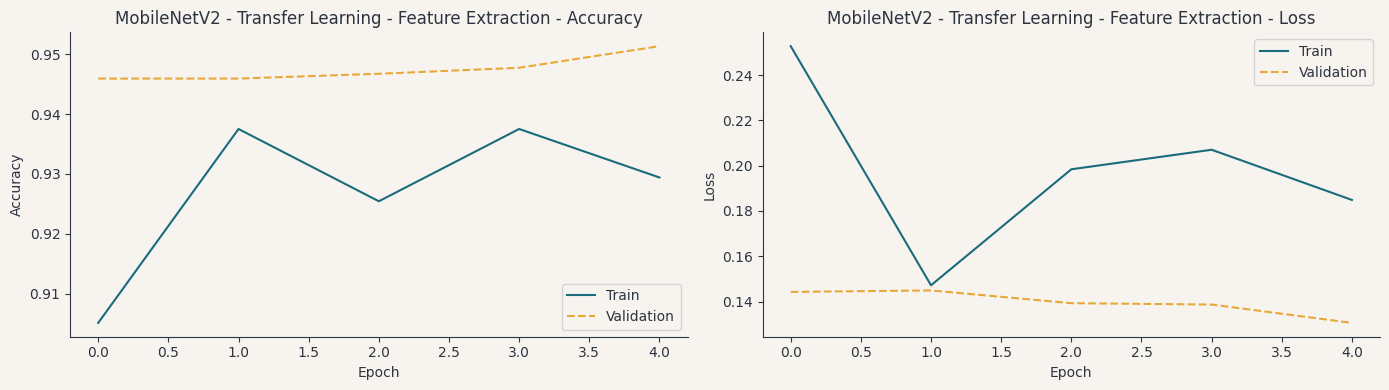

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_mobilenetv2_transfer_training_history.png


In [ ]:
if not RUN_MOBILENET_64: raise StopIteration  # Control Panel skip
# ── Cell 52 ──
plot_training_history(history_transfer, title=f'{MODEL_NAME} - Feature Extraction',
                      slug=MODEL_SLUG + '_transfer')


In [ ]:
if not RUN_MOBILENET_64: raise StopIteration  # Control Panel skip
# ── Cell 53 ──
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history_finetune = transfer_model.fit(
    train_gen,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=15,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/15
311/311 - 16s - 51ms/step - accuracy: 0.8540 - loss: 0.3690 - val_accuracy: 0.9385 - val_loss: 0.1660 - learning_rate: 1.0000e-05
Epoch 2/15
311/311 - 2s - 7ms/step - accuracy: 0.8438 - loss: 0.3202 - val_accuracy: 0.9385 - val_loss: 0.1658 - learning_rate: 1.0000e-05
Epoch 3/15
311/311 - 11s - 36ms/step - accuracy: 0.8950 - loss: 0.2710 - val_accuracy: 0.9369 - val_loss: 0.1686 - learning_rate: 1.0000e-05
Epoch 4/15
311/311 - 2s - 7ms/step - accuracy: 0.8594 - loss: 0.2323 - val_accuracy: 0.9369 - val_loss: 0.1687 - learning_rate: 5.0000e-06
Epoch 5/15
311/311 - 11s - 36ms/step - accuracy: 0.9050 - loss: 0.2529 - val_accuracy: 0.9413 - val_loss: 0.1585 - learning_rate: 5.0000e-06


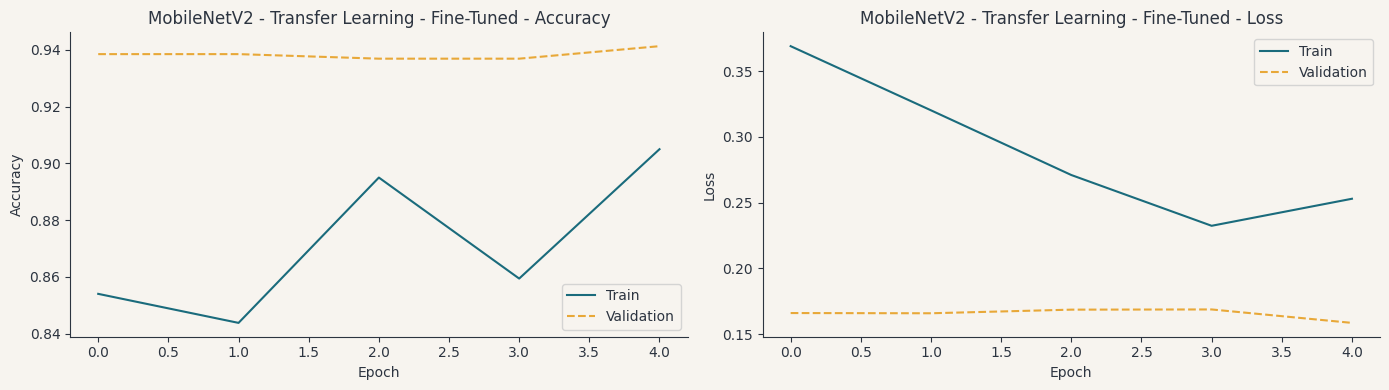

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_mobilenetv2_finetuned_training_history.png


In [ ]:
if not RUN_MOBILENET_64: raise StopIteration  # Control Panel skip
# ── Cell 54 ──
plot_training_history(history_finetune, title=f'{MODEL_NAME} - Fine-Tuned',
                      slug=MODEL_SLUG + '_finetuned')


<!-- Cell 55 -->
---
## 10. MobileNetV2 - Transfer Learning - Model Evaluation



  MobileNetV2 - Transfer Learning - Fine-Tuned - Test Set Evaluation
              precision    recall  f1-score   support

  Uninfected       0.90      0.97      0.93      1300
 Parasitized       0.97      0.89      0.93      1300

    accuracy                           0.93      2600
   macro avg       0.93      0.93      0.93      2600
weighted avg       0.93      0.93      0.93      2600

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_mobilenetv2_finetuned_cm.png
Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_mobilenetv2_finetuned_roc.png


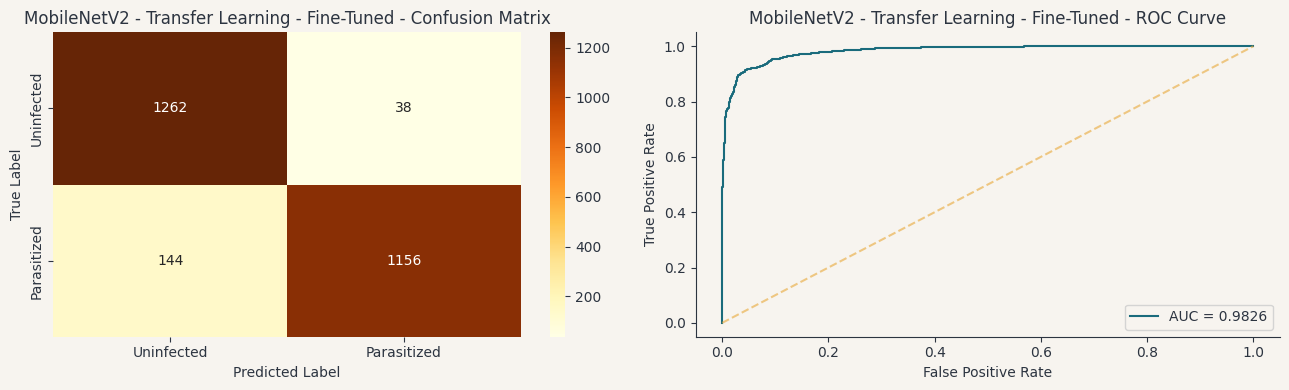

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_mobilenetv2_finetuned_evaluation.png


In [ ]:
if not RUN_MOBILENET_64: raise StopIteration  # Control Panel skip
# ── Cell 56 ──
y_pred_transfer, y_prob_transfer = evaluate_model(
    transfer_model, X_test, y_test, model_name=f'{MODEL_NAME} - Fine-Tuned',
    slug=MODEL_SLUG + '_finetuned'
)


<!-- Cell 57 -->
### Observations & Insights

> **Fill in after running evaluation cells above.**
>
> - Overall accuracy on test set: ...
> - Precision / Recall for Parasitized class: ...
> - False negative rate (missed parasitized cases): ...
> - Notable patterns in training curves: ...
> - AUC-ROC score: ...


<!-- Cell 57a -->
---
## 10a. MobileNetV2 - Class Weighted - Model Building

This section repeats the MobileNetV2 fine-tuning experiment with class weighting applied, matching the CNN3 training recipe. Architecture, augmentation, and optimizer settings are held constant. The only change is `class_weight={0: 1.0, 1: 2.0}` in both the feature-extraction and fine-tuning `.fit()` calls.

The question this answers: is MobileNetV2's recall gap (84.62% vs CNN3's 99.15%) architectural, or is it recoverable through training configuration alone?

In [ ]:
if not RUN_MOBILENET_WEIGHTED: raise StopIteration  # Control Panel skip
# ── Cell 57b ──
MODEL_SLUG_W = 'mobilenetv2_weighted'
MODEL_NAME_W = 'MobileNetV2 - Class Weighted'

# Fresh backbone with imagenet weights (identical architecture to the unweighted run)
base_model_w = keras.applications.MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights='imagenet'
)
base_model_w.trainable = False

inputs_w = keras.Input(shape=(64, 64, 3))
x_w = keras.applications.mobilenet_v2.preprocess_input(inputs_w * 255.0)
x_w = base_model_w(x_w, training=False)
x_w = layers.GlobalAveragePooling2D()(x_w)
x_w = layers.Dropout(0.3)(x_w)
x_w = layers.Dense(128, activation='relu')(x_w)
x_w = layers.Dropout(0.3)(x_w)
outputs_w = layers.Dense(1, activation='sigmoid')(x_w)

transfer_model_w = keras.Model(inputs_w, outputs_w, name='mobilenetv2_weighted')
transfer_model_w.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall')],
)

CLASS_WEIGHT_MNV2 = {0: 1.0, 1: 2.0}

callbacks_mnv2_w = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

train_gen_w = datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)

transfer_model_w.summary()

In [ ]:
if not RUN_MOBILENET_WEIGHTED: raise StopIteration  # Control Panel skip
# ── Cell 57c ── Feature extraction pass (backbone frozen)
history_transfer_w = transfer_model_w.fit(
    train_gen_w,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=callbacks_mnv2_w,
    class_weight=CLASS_WEIGHT_MNV2,
    verbose=2,
)

In [ ]:
if not RUN_MOBILENET_WEIGHTED: raise StopIteration  # Control Panel skip
# ── Cell 57d ──
plot_training_history(history_transfer_w, title=f'{MODEL_NAME_W} - Feature Extraction',
                      slug=MODEL_SLUG_W + '_transfer')

In [ ]:
if not RUN_MOBILENET_WEIGHTED: raise StopIteration  # Control Panel skip
# ── Cell 57e ── Fine-tuning pass (unfreeze last 30 layers)
base_model_w.trainable = True
for layer in base_model_w.layers[:-30]:
    layer.trainable = False

transfer_model_w.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall')],
)

history_finetune_w = transfer_model_w.fit(
    train_gen_w,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=15,
    callbacks=callbacks_mnv2_w,
    class_weight=CLASS_WEIGHT_MNV2,
    verbose=2,
)

In [ ]:
if not RUN_MOBILENET_WEIGHTED: raise StopIteration  # Control Panel skip
# ── Cell 57f ──
plot_training_history(history_finetune_w, title=f'{MODEL_NAME_W} - Fine-Tuned',
                      slug=MODEL_SLUG_W + '_finetuned')

<!-- Cell 57g -->
---
## 10b. MobileNetV2 - Class Weighted - Model Evaluation

In [ ]:
if not RUN_MOBILENET_WEIGHTED: raise StopIteration  # Control Panel skip
# ── Cell 57h ──
y_pred_transfer_w, y_prob_transfer_w = evaluate_model(
    transfer_model_w, X_test, y_test, model_name=f'{MODEL_NAME_W} - Fine-Tuned',
    slug=MODEL_SLUG_W + '_finetuned'
)

<!-- Cell 57i -->
### Observations & Insights

> **Fill in after running evaluation cells above.**
>
> - Overall accuracy on test set: ...
> - Precision / Recall for Parasitized class: ...
> - False negative rate (missed parasitized cases): ...
> - Notable patterns in training curves (vs. unweighted MNV2): ...
> - AUC-ROC: ...

<!-- Cell 71 -->
---
## 13. CNN3 - 32px Resolution Experiment - Model Building

Retraining CNN3 (identical architecture, class weighting ×2, early stopping on val_loss) with images downscaled to 32×32 to test whether recall is maintained at ultra-low resolution.

In [ ]:
if not RUN_CNN3_32: raise StopIteration  # Control Panel skip
# ── Cell 72 ──
# ── data-32 ──
IMG_SIZE_32 = 32

_cache_32 = os.path.join(CACHE_DIR, 'cache_32px.npz')

if os.path.exists(_cache_32):
    print(f'Loading 32px data from cache: {_cache_32}')
    _c32 = np.load(_cache_32)
    X_train_full_32, y_train_full_32 = _c32['X_train_full'], _c32['y_train_full']
    X_test_32,       y_test_32       = _c32['X_test'],       _c32['y_test']
    print(f'  X_train_full_32: {X_train_full_32.shape}  X_test_32: {X_test_32.shape}')
else:
    if _on_colab:
        raise RuntimeError('32px cache not found on Drive. Generate it locally first.')
    print('Loading 32px training images...')
    X_train_full_32, y_train_full_32 = load_images_from_dir(TRAIN_DIR, CLASSES, LABEL_MAP, IMG_SIZE_32)
    print(f'  Loaded: {X_train_full_32.shape}')
    print('Loading 32px test images...')
    X_test_32, y_test_32 = load_images_from_dir(TEST_DIR, CLASSES, LABEL_MAP, IMG_SIZE_32)
    print(f'  Loaded: {X_test_32.shape}')
    print(f'Saving 32px cache to {_cache_32} ...')
    np.savez_compressed(_cache_32,
                        X_train_full=X_train_full_32, y_train_full=y_train_full_32,
                        X_test=X_test_32,             y_test=y_test_32)
    print('Cache saved.')

# Normalize
X_train_full_32 = X_train_full_32 / 255.0
X_test_32       = X_test_32       / 255.0

# 80/20 stratified split
X_train_32, X_val_32, y_train_32, y_val_32 = train_test_split(
    X_train_full_32, y_train_full_32,
    test_size=0.2, random_state=SEED, stratify=y_train_full_32
)
del X_train_full_32  # free memory

print(f'Train 32px : {X_train_32.shape}  |  Labels: {Counter(y_train_32)}')
print(f'Val 32px   : {X_val_32.shape}    |  Labels: {Counter(y_val_32)}')
print(f'Test 32px  : {X_test_32.shape}   |  Labels: {Counter(y_test_32)}')


Loading 32px data from cache: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/cell_images/cache_32px.npz
  X_train_full_32: (24958, 32, 32, 3)  X_test_32: (2600, 32, 32, 3)
Train 32px : (19966, 32, 32, 3)  |  Labels: Counter({np.int64(1): 10065, np.int64(0): 9901})
Val 32px   : (4992, 32, 32, 3)    |  Labels: Counter({np.int64(1): 2517, np.int64(0): 2475})
Test 32px  : (2600, 32, 32, 3)   |  Labels: Counter({np.int64(1): 1300, np.int64(0): 1300})


In [ ]:
if not RUN_CNN3_32: raise StopIteration  # Control Panel skip
# ── Cell 73 ──
# ── build-cnn3-32 ──
MODEL_SLUG_32 = 'cnn3_32'
MODEL_NAME_32 = 'CNN3 - 32px Downscale'

# Lazy re-definition: build_improved_cnn lives in the RUN_CNN2 block;
# re-define here if CNN2 was skipped so this section is self-contained.
if 'build_improved_cnn' not in globals():
    def build_improved_cnn(input_shape=(64, 64, 3)):
        model = models.Sequential([
            layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
            layers.BatchNormalization(),
            layers.Conv2D(32, (3,3), activation='relu', padding='same'),
            layers.MaxPooling2D(2,2),
            layers.Dropout(0.25),
            layers.Conv2D(64, (3,3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(64, (3,3), activation='relu', padding='same'),
            layers.MaxPooling2D(2,2),
            layers.Dropout(0.25),
            layers.Conv2D(128, (3,3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2,2),
            layers.Dropout(0.25),
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(1, activation='sigmoid'),
        ], name='improved_cnn')
        return model

cnn3_32_model = build_improved_cnn(input_shape=(IMG_SIZE_32, IMG_SIZE_32, 3))
cnn3_32_model._name = 'cnn3_32px'

cnn3_32_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall')],
)
cnn3_32_model.summary()


Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,601 (678.13 KB)

 Trainable params: 173,153 (676.38 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
if not RUN_CNN3_32: raise StopIteration  # Control Panel skip
# ── Cell 74 ──
# ── train-cnn3-32 ──

# Lazy re-definition: datagen lives in the RUN_CNN2 block.
if 'datagen' not in globals():
    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        vertical_flip=True,
        zoom_range=0.1,
        fill_mode='nearest'
    )

callbacks_cnn3_32 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
]

train_gen_32 = datagen.flow(X_train_32, y_train_32, batch_size=BATCH_SIZE, seed=SEED)

history_cnn3_32 = cnn3_32_model.fit(
    train_gen_32,
    steps_per_epoch=len(X_train_32) // BATCH_SIZE,
    validation_data=(X_val_32, y_val_32),
    epochs=40,
    callbacks=callbacks_cnn3_32,
    class_weight={0: 1.0, 1: 2.0},
    verbose=2,
)


Epoch 1/40
311/311 - 11s - 36ms/step - accuracy: 0.8556 - loss: 0.4196 - recall: 0.9105 - val_accuracy: 0.5038 - val_loss: 1.6325 - val_recall: 0.0159 - learning_rate: 0.0010
Epoch 2/40
311/311 - 1s - 2ms/step - accuracy: 0.9844 - loss: 0.1882 - recall: 0.9706 - val_accuracy: 0.5046 - val_loss: 1.5956 - val_recall: 0.0175 - learning_rate: 0.0010
Epoch 3/40
311/311 - 9s - 30ms/step - accuracy: 0.9633 - loss: 0.1564 - recall: 0.9621 - val_accuracy: 0.9700 - val_loss: 0.0932 - val_recall: 0.9444 - learning_rate: 0.0010
Epoch 4/40
311/311 - 1s - 2ms/step - accuracy: 0.9844 - loss: 0.0963 - recall: 0.9630 - val_accuracy: 0.9714 - val_loss: 0.0862 - val_recall: 0.9476 - learning_rate: 0.0010
Epoch 5/40
311/311 - 9s - 29ms/step - accuracy: 0.9718 - loss: 0.1246 - recall: 0.9725 - val_accuracy: 0.9794 - val_loss: 0.0685 - val_recall: 0.9809 - learning_rate: 0.0010
Epoch 6/40
311/311 - 1s - 2ms/step - accuracy: 0.9844 - loss: 0.0602 - recall: 1.0000 - val_accuracy: 0.9794 - val_loss: 0.0760 - v

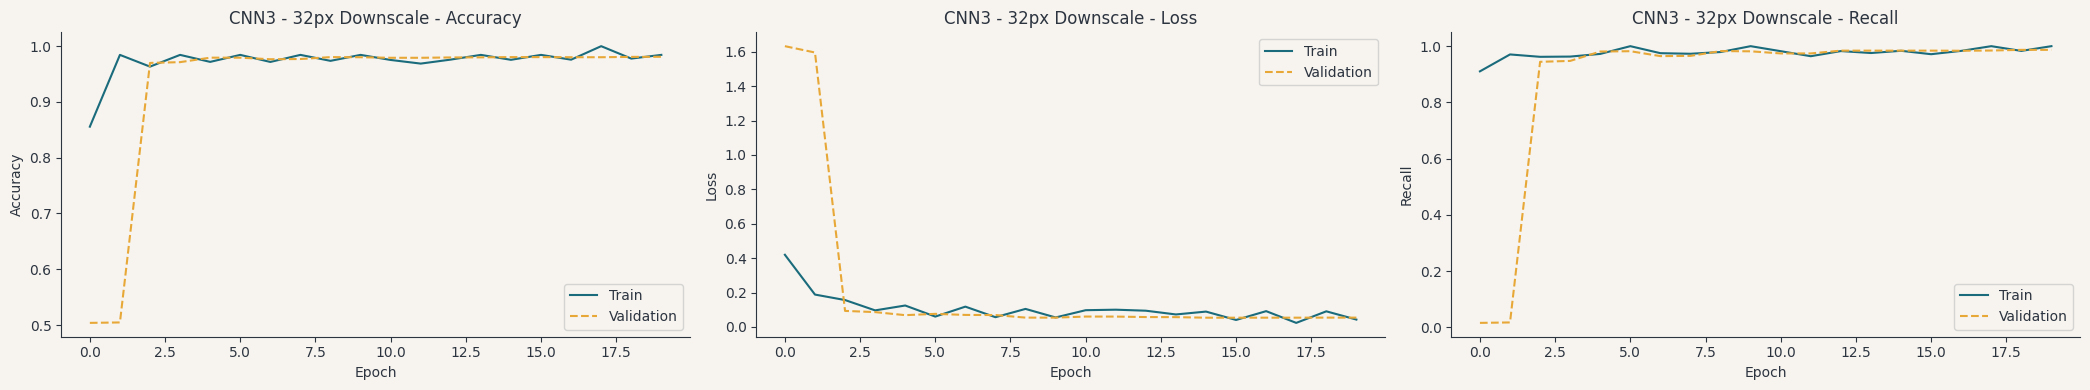

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn3_32_training_history.png


In [ ]:
if not RUN_CNN3_32: raise StopIteration  # Control Panel skip
# ── Cell 75 ──
# ── plot-cnn3-32 ──
plot_training_history(history_cnn3_32, title=MODEL_NAME_32, slug=MODEL_SLUG_32)


<!-- Cell 76 -->
---
## 14. CNN3 - 32px Resolution Experiment - Model Evaluation


  CNN3 - 32px Downscale - Test Set Evaluation
              precision    recall  f1-score   support

  Uninfected       0.99      0.98      0.99      1300
 Parasitized       0.98      0.99      0.99      1300

    accuracy                           0.99      2600
   macro avg       0.99      0.99      0.99      2600
weighted avg       0.99      0.99      0.99      2600

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn3_32_cm.png
Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn3_32_roc.png


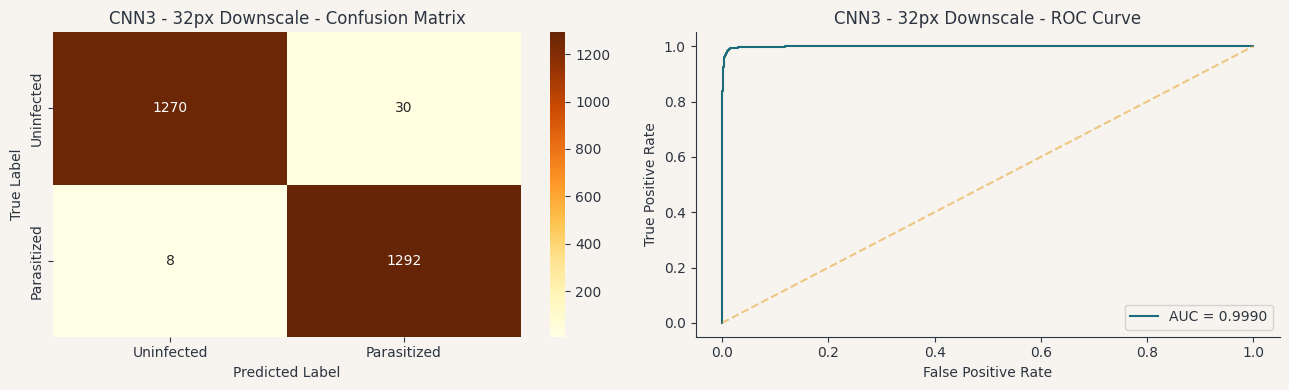

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn3_32_evaluation.png


In [ ]:
if not RUN_CNN3_32: raise StopIteration  # Control Panel skip
# ── Cell 77 ──
# ── eval-cnn3-32 ──
y_pred_cnn3_32, y_prob_cnn3_32 = evaluate_model(
    cnn3_32_model, X_test_32, y_test_32,
    model_name=MODEL_NAME_32, slug=MODEL_SLUG_32
)


<!-- Cell 78 -->
<!-- cnn3-32-obs -->
### Observations & Insights

> **Fill in after evaluating.** Key question: does recall hold above 95% at 32×32, or does halving the resolution cross a morphological information threshold?

In [ ]:
if not RUN_CNN3_32: raise StopIteration  # Control Panel skip
# ── Cell 79 ──
# ── cnn3-32-triage-define ──
# MODEL_SLUG/MODEL_NAME pinned so this cell is safe to run in any kernel state.
MODEL_SLUG = 'cnn3_32'
MODEL_NAME = 'CNN3 - 32px Downscale'

# Confidence-Based Triage: Abstention Classifier for CNN3-32px
# Samples with sigmoid output in the uncertainty band are flagged for
# expert review rather than committed to either class.

CONF_LOW  = 0.35   # below → Uninfected (high confidence)
CONF_HIGH = 0.65   # above → Parasitized (high confidence)
# Between CONF_LOW and CONF_HIGH → Borderline (refer to microscopist)

probs   = y_prob_cnn3_32.flatten()
triage  = np.where(probs < CONF_LOW,  'Uninfected',
          np.where(probs > CONF_HIGH, 'Parasitized', 'Borderline'))

n_total      = len(probs)
n_uninf      = (triage == 'Uninfected').sum()
n_para       = (triage == 'Parasitized').sum()
n_borderline = (triage == 'Borderline').sum()

print('=' * 54)
print(f'  CNN3-32px Confidence Triage  (band {CONF_LOW}–{CONF_HIGH})')
print('=' * 54)
print(f'  Automated Uninfected  : {n_uninf:>5}  ({n_uninf/n_total:.1%})')
print(f'  Automated Parasitized : {n_para:>5}  ({n_para/n_total:.1%})')
print(f'  Borderline (refer)    : {n_borderline:>5}  ({n_borderline/n_total:.1%})')
print('=' * 54)

borderline_mask = triage == 'Borderline'
if borderline_mask.sum() > 0:
    bl_true = y_test_32[borderline_mask]
    print(f'\n  Borderline breakdown:')
    print(f'    Parasitized : {bl_true.sum()} ({bl_true.mean():.1%} of referred)')
    print(f'    Uninfected  : {(1 - bl_true).sum()} ({(1-bl_true).mean():.1%} of referred)')

uninf_mask = triage == 'Uninfected'
fn_automated = (y_test_32[uninf_mask] == 1).sum()
print(f'\n  False negatives in automated Uninfected bucket: {fn_automated}')
print(f'  (vs {int((y_test_32 == 1).sum())} total Parasitized in test set)')

# Persist triage results to results.json
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as f:
        _results = json.load(f)
else:
    _results = {'models': {}}
    print('results.json not found — starting fresh triage record.')

if 'cnn3_32' not in _results['models']:
    _results['models']['cnn3_32'] = {}
_results['models']['cnn3_32']['triage'] = {
    'conf_low':                  CONF_LOW,
    'conf_high':                 CONF_HIGH,
    'n_total':                   int(n_total),
    'n_automated_uninf':         int(n_uninf),
    'n_automated_para':          int(n_para),
    'n_borderline':              int(n_borderline),
    'pct_referred':              round(n_borderline / n_total * 100, 2),
    'fn_in_auto_bucket':         int(fn_automated),
    'parasitized_in_borderline': int(bl_true.sum()) if borderline_mask.sum() > 0 else 0,
}

# Derive system-level recall assuming microscopist catches all referred (borderline) cells.
# system_fn = only the cells auto-classified as Uninfected that are actually Parasitized.
_n_para_total = int(y_test_32.sum())
_sys_fn = int(fn_automated)
_results['models']['cnn3_32']['triage']['system_fn']     = _sys_fn
_results['models']['cnn3_32']['triage']['system_recall'] = round((_n_para_total - _sys_fn) / _n_para_total, 4)

with open(RESULTS_FILE, 'w') as f:
    json.dump(_results, f, indent=2)

print(f'Triage results written to {RESULTS_FILE}')


  CNN3-32px Confidence Triage  (band 0.35–0.65)
  Automated Uninfected  :  1257  (48.3%)
  Automated Parasitized :  1304  (50.2%)
  Borderline (refer)    :    39  (1.5%)

  Borderline breakdown:
    Parasitized : 8 (20.5% of referred)
    Uninfected  : 31 (79.5% of referred)

  False negatives in automated Uninfected bucket: 5
  (vs 1300 total Parasitized in test set)
Triage results written to /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/results.json


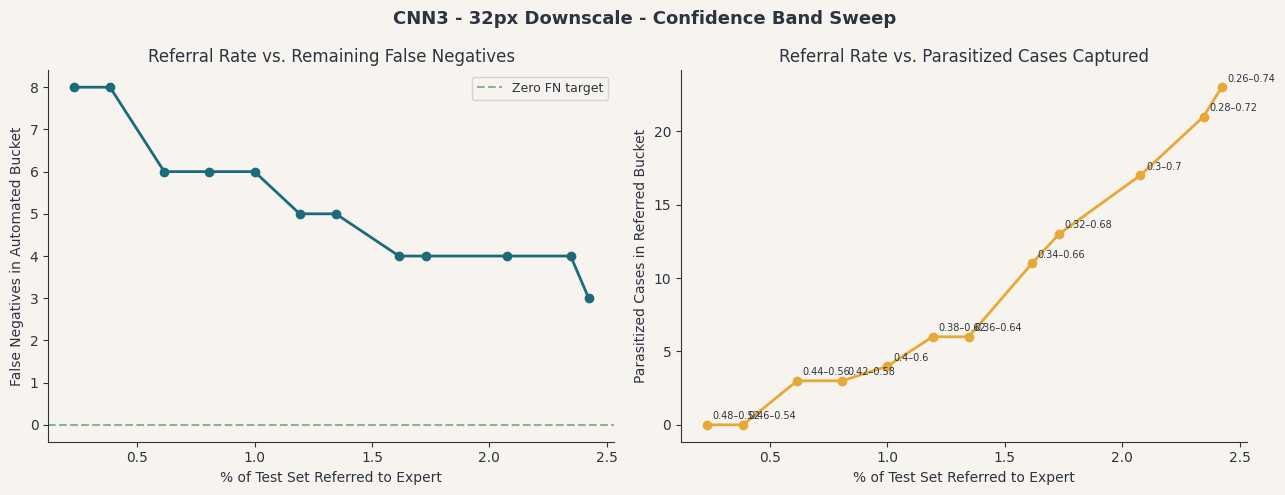

Saved: fig_cnn3_32_triage_sweep.png

Sweep summary:
     band  pct_referred  fn_automated  para_in_border
0.48–0.52      0.230769             8               0
0.46–0.54      0.384615             8               0
0.44–0.56      0.615385             6               3
0.42–0.58      0.807692             6               3
  0.4–0.6      1.000000             6               4
0.38–0.62      1.192308             5               6
0.36–0.64      1.346154             5               6
0.34–0.66      1.615385             4              11
0.32–0.68      1.730769             4              13
  0.3–0.7      2.076923             4              17
0.28–0.72      2.346154             4              21
0.26–0.74      2.423077             3              23


In [ ]:
if not RUN_CNN3_32: raise StopIteration  # Control Panel skip
# ── Cell 80 ──
# ── cnn3-32-triage-sweep ──
# Triage Band Sweep for CNN3-32px model
MODEL_SLUG = 'cnn3_32'
MODEL_NAME = 'CNN3 - 32px Downscale'

probs_32 = y_prob_cnn3_32.flatten()

half_widths = np.arange(0.02, 0.26, 0.02)
sweep = []
for hw in half_widths:
    lo, hi = round(0.5 - hw, 2), round(0.5 + hw, 2)
    t = np.where(probs_32 < lo, 'Uninfected',
        np.where(probs_32 > hi, 'Parasitized', 'Borderline'))
    uninf_m  = t == 'Uninfected'
    border_m = t == 'Borderline'
    fn_auto  = int((y_test_32[uninf_m] == 1).sum()) if uninf_m.any() else 0
    para_in_border = int(y_test_32[border_m].sum()) if border_m.any() else 0
    sweep.append({
        'half_width': hw,
        'band': f'{lo}\u2013{hi}',
        'pct_referred': border_m.mean() * 100,
        'fn_automated': fn_auto,
        'para_in_border': para_in_border,
    })

df_sweep = pd.DataFrame(sweep)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'{MODEL_NAME} - Confidence Band Sweep', fontsize=13, fontweight='bold')

axes[0].plot(df_sweep['pct_referred'], df_sweep['fn_automated'],
             marker='o', color=CLAROS['teal'], linewidth=2)
axes[0].set_xlabel('% of Test Set Referred to Expert')
axes[0].set_ylabel('False Negatives in Automated Bucket')
axes[0].set_title('Referral Rate vs. Remaining False Negatives')
axes[0].axhline(0, color=CLAROS['sage'], linestyle='--', alpha=0.7, label='Zero FN target')
axes[0].legend(fontsize=9)

axes[1].plot(df_sweep['pct_referred'], df_sweep['para_in_border'],
             marker='o', color=CLAROS['amber'], linewidth=2)
axes[1].set_xlabel('% of Test Set Referred to Expert')
axes[1].set_ylabel('Parasitized Cases in Referred Bucket')
axes[1].set_title('Referral Rate vs. Parasitized Cases Captured')

for _, row in df_sweep.iterrows():
    axes[1].annotate(row['band'], (row['pct_referred'], row['para_in_border']),
                     textcoords='offset points', xytext=(4, 4), fontsize=7,
                     color=CLAROS['dark'])

plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, f'fig_{MODEL_SLUG}_triage_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig_{MODEL_SLUG}_triage_sweep.png')

print('\nSweep summary:')
print(df_sweep[['band','pct_referred','fn_automated','para_in_border']].to_string(index=False))


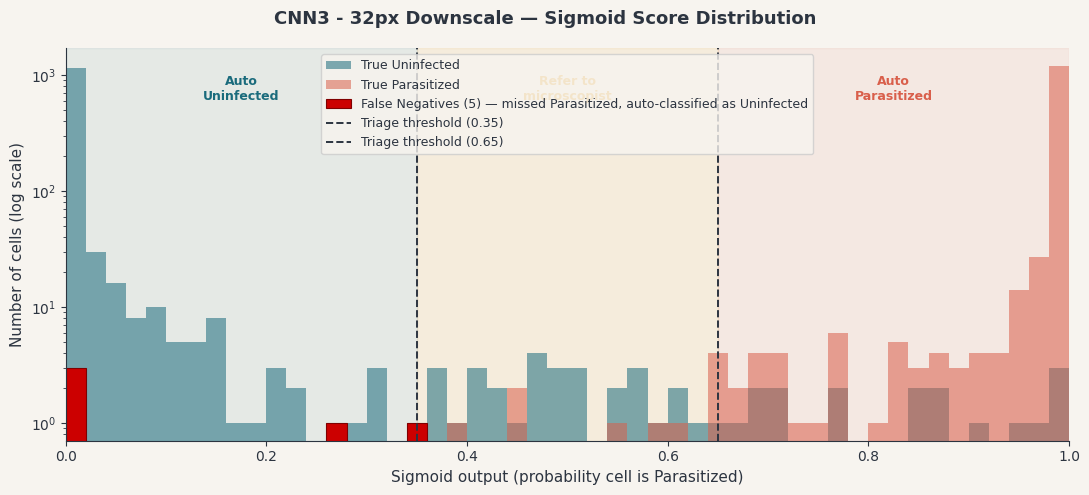

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/figures/fig_cnn3_32_score_dist.png
FNs in auto-Uninfected bucket: 5 (scores: [0.004672062583267689, 0.013050450943410397, 0.014712506905198097, 0.27336829900741577, 0.3444230854511261])


In [ ]:
if not RUN_CNN3_32: raise StopIteration  # Control Panel skip
# ── Cell 81 ──
# ── cnn3-32-score-dist ──
# Score distribution histogram: sigmoid output by true label, FNs highlighted.
MODEL_SLUG = 'cnn3_32'
MODEL_NAME = 'CNN3 - 32px Downscale'
CONF_LOW  = 0.35
CONF_HIGH = 0.65

probs_32 = y_prob_cnn3_32.flatten()
uninf_scores = probs_32[y_test_32 == 0]
para_scores  = probs_32[y_test_32 == 1]
fn_scores    = probs_32[(y_test_32 == 1) & (probs_32 < CONF_LOW)]  # FNs in auto-uninf bucket

bins = np.linspace(0, 1, 51)

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle(f'{MODEL_NAME} — Sigmoid Score Distribution', fontsize=13, fontweight='bold')

# Zone shading
ax.axvspan(0,          CONF_LOW,  alpha=0.08, color=CLAROS['teal'],  zorder=0)
ax.axvspan(CONF_LOW,   CONF_HIGH, alpha=0.10, color=CLAROS['amber'], zorder=0)
ax.axvspan(CONF_HIGH,  1,         alpha=0.08, color=CLAROS['coral'], zorder=0)

# Histograms
ax.hist(uninf_scores, bins=bins, color=CLAROS['teal'],  alpha=0.55, label='True Uninfected')
ax.hist(para_scores,  bins=bins, color=CLAROS['coral'], alpha=0.55, label='True Parasitized')

# FN overlay
ax.hist(fn_scores, bins=bins, color='#CC0000', alpha=1.0,
        label=f'False Negatives ({len(fn_scores)}) — missed Parasitized, auto-classified as Uninfected',
        edgecolor='#800000', linewidth=0.8)

# Threshold lines
ax.axvline(CONF_LOW,  color=CLAROS['dark'], linestyle='--', linewidth=1.4,
           label=f'Triage threshold ({CONF_LOW})')
ax.axvline(CONF_HIGH, color=CLAROS['dark'], linestyle='--', linewidth=1.4,
           label=f'Triage threshold ({CONF_HIGH})')

ax.set_yscale('log')
# Zone labels — placed via axis transform so log scale doesn't affect y position
for x_pos, label, color in [
    (CONF_LOW / 2,                  'Auto\nUninfected',      CLAROS['teal']),
    ((CONF_LOW + CONF_HIGH) / 2,    'Refer to\nmicroscopist', CLAROS['amber']),
    ((CONF_HIGH + 1) / 2,           'Auto\nParasitized',     CLAROS['coral']),
]:
    ax.text(x_pos, 0.93, label, ha='center', va='top', fontsize=9,
            color=color, fontweight='bold', transform=ax.get_xaxis_transform())

ax.set_xlabel('Sigmoid output (probability cell is Parasitized)', fontsize=11)
ax.set_yscale('log')
ax.set_ylabel('Number of cells (log scale)', fontsize=11)
ax.legend(fontsize=9, loc='upper center')
ax.set_xlim(0, 1)

plt.tight_layout()
fname = os.path.join(FIGURES_DIR, f'fig_{MODEL_SLUG}_score_dist.png')
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fname}')
print(f'FNs in auto-Uninfected bucket: {len(fn_scores)} '
      f'(scores: {sorted(fn_scores.tolist())})')


In [ ]:
if not RUN_CNN3_32: raise StopIteration  # Control Panel skip
# ── Cell 82 ──
# ── cnn3-32-score-histogram-export ──
# Export sigmoid score histogram to results.json so the HTML triage slider
# can compute FN / FP / referral counts dynamically at any threshold pair.
MODEL_SLUG = 'cnn3_32'

BIN_WIDTH = 0.01
bin_edges = np.round(np.arange(0, 1 + BIN_WIDTH, BIN_WIDTH), 10)
n_bins    = len(bin_edges) - 1  # 100 bins

probs_32 = y_prob_cnn3_32.flatten()

uninf_counts, _  = np.histogram(probs_32[y_test_32 == 0], bins=bin_edges)
para_counts,  _  = np.histogram(probs_32[y_test_32 == 1], bins=bin_edges)

# Sanity check
print(f'Bins: {n_bins}  |  bin width: {BIN_WIDTH}')
print(f'Total Uninfected: {uninf_counts.sum()} (expect {(y_test_32 == 0).sum()})')
print(f'Total Parasitized: {para_counts.sum()} (expect {(y_test_32 == 1).sum()})')
print(f'FNs at 0.35 lower threshold: '
      f'{para_counts[:35].sum()} (scores < 0.35)')

# Write to results.json
with open(RESULTS_FILE) as f:
    _results = json.load(f)

if MODEL_SLUG not in _results['models']:
    _results['models'][MODEL_SLUG] = {}

_results['models'][MODEL_SLUG]['score_histogram'] = {
    'bin_width':          BIN_WIDTH,
    'n_bins':             int(n_bins),
    'uninfected_counts':  uninf_counts.tolist(),
    'parasitized_counts': para_counts.tolist(),
}

with open(RESULTS_FILE, 'w') as f:
    json.dump(_results, f, indent=2)

print(f'Score histogram written to {RESULTS_FILE}')


Bins: 100  |  bin width: 0.01
Total Uninfected: 1300 (expect 1300)
Total Parasitized: 1300 (expect 1300)
FNs at 0.35 lower threshold: 5 (scores < 0.35)
Score histogram written to /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/results.json


<!-- Cell 83 -->
---
## 15. Model Comparison

In [ ]:
# ── Cell 84 ──
def metrics_dict(y_true, y_pred, y_prob, name):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y_true, y_prob), 4),
    }

# Only include rows where all required variables are defined
_g = globals()
_candidates = [
    ('CNN1 - Baseline',                                    'y_pred_baseline',       'y_prob_baseline',       'y_test'),
    ('CNN2 - Augmented (default threshold)',               'y_pred_improved',       'y_prob_improved',       'y_test'),
    ('CNN2 - Augmented (tuned threshold)',                 'y_pred_improved_tuned', 'y_prob_improved',       'y_test'),
    ('CNN3 - Recall-Optimized',                           'y_pred_cnn3',           'y_prob_cnn3',           'y_test'),
    ('MobileNetV2 Fine-Tuned (64px)',                     'y_pred_transfer',       'y_prob_transfer',       'y_test'),
    ('CNN3 - 32px Downscale',                             'y_pred_cnn3_32',        'y_prob_cnn3_32',        'y_test_32'),
]

rows = []
for name, pred_var, prob_var, test_var in _candidates:
    if pred_var in _g and prob_var in _g and test_var in _g:
        rows.append(metrics_dict(_g[test_var], _g[pred_var], _g[prob_var], name))
    else:
        print(f'Skipping {name!r} - predictions not in scope this run')

if rows:
    comparison_df = pd.DataFrame(rows)
    comparison_df.set_index('Model', inplace=True)
    display(comparison_df.style.highlight_max(axis=0, color='#b2dfdb'))
else:
    print('No models evaluated this run - comparison table skipped.')


Skipping 'MobileNetV2 Fine-Tuned (128px)' - predictions not in scope this run


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
CNN1 - Baseline,0.986900,0.983900,0.990000,0.987000,0.999300
CNN2 - Augmented (default threshold),0.504600,1.000000,0.009200,0.018300,0.975400
CNN2 - Augmented (tuned threshold),0.948800,0.998300,0.899200,0.946200,0.975400
CNN3 - Recall-Optimized,0.985800,0.981700,0.990000,0.985800,0.998900
MobileNetV2 Fine-Tuned (64px),0.930000,0.968200,0.889200,0.927000,0.982600
CNN3 - 32px Downscale,0.985400,0.977300,0.993800,0.985500,0.999000


In [ ]:
# ── Cell 85 ──

def _model_block(y_true, y_pred, y_prob, name, slug, history=None, threshold=0.5, extra=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel().tolist()
    block = {
        'name':    name,
        'slug':    slug,
        'threshold_used': threshold,
        'test': {
            'accuracy':         round(accuracy_score(y_true, y_pred), 4),
            'precision':        round(precision_score(y_true, y_pred, zero_division=0), 4),
            'recall':           round(recall_score(y_true, y_pred, zero_division=0), 4),
            'f1':               round(f1_score(y_true, y_pred, zero_division=0), 4),
            'auc_roc':          round(roc_auc_score(y_true, y_prob), 4),
            'confusion_matrix': [[int(tn), int(fp)], [int(fn), int(tp)]],
            'false_negative_rate': round(fn / (fn + tp), 4) if (fn + tp) > 0 else None,
            'false_positive_rate': round(fp / (fp + tn), 4) if (fp + tn) > 0 else None,
        },
    }
    if history is not None:
        h = history.history
        block['training'] = {
            'epochs_trained':       len(h['loss']),
            'final_train_accuracy': round(float(h['accuracy'][-1]), 4),
            'final_val_accuracy':   round(float(h['val_accuracy'][-1]), 4),
            'final_train_loss':     round(float(h['loss'][-1]), 4),
            'final_val_loss':       round(float(h['val_loss'][-1]), 4),
            'best_val_loss':        round(float(min(h['val_loss'])), 4),
            'best_epoch':           int(h['val_loss'].index(min(h['val_loss']))) + 1,
        }
        if 'recall' in h:
            block['training']['final_train_recall'] = round(float(h['recall'][-1]), 4)
            block['training']['final_val_recall']   = round(float(h['val_recall'][-1]), 4)
    if extra:
        block.update(extra)
    return block

_g = globals()
# Load existing results.json and merge — preserves models from previous runs
_existing = {}
if os.path.exists(RESULTS_FILE):
    try:
        with open(RESULTS_FILE) as _f:
            _existing = json.load(_f)
        print(f'Loaded existing results.json ({list(_existing.get("models", {}).keys())})')
    except Exception as _e:
        print(f'Could not read existing results.json: {_e}')

results = {
    'generated_at': datetime.now().isoformat(timespec='seconds'),
    'dataset': {
        'train_size':   int(len(X_train)),
        'val_size':     int(len(X_val)),
        'test_size':    int(len(X_test)),
        'image_size':   [IMG_SIZE] * 2 + [3],
        'classes':      ['Uninfected', 'Parasitized'],
    },
    'models': dict(_existing.get('models', {})),  # start from existing models
}
# Preserve best_model from existing if present
if 'best_model' in _existing:
    results['best_model'] = _existing['best_model']

# Add each model only if its variables are defined
_candidates = [
    ('cnn1',          'CNN1 - Baseline',                  'y_pred_baseline',       'y_prob_baseline',       'history_baseline',    0.5,  None),
    ('cnn2',          'CNN2 - Augmented',                  'y_pred_improved',       'y_prob_improved',       'history_improved',    0.5,  None),
    ('cnn2_tuned',    'CNN2 - Augmented (tuned threshold)','y_pred_improved_tuned', 'y_prob_improved',       None,                  None, None),
    ('cnn3',          'CNN3 - Recall-Optimized',           'y_pred_cnn3',           'y_prob_cnn3',           'history_cnn3',        0.5,  None),
    ('mobilenetv2',     'MobileNetV2 - Transfer Learning',        'y_pred_transfer',       'y_prob_transfer',       'history_finetune',     0.5, None),
    ('mobilenetv2_weighted',     'MobileNetV2 - Class Weighted'  ,        'y_pred_transfer_w',       'y_prob_transfer_w',       'history_finetune_w',     0.5, None),
    ('cnn3_32',          'CNN3 - 32px Downscale',                  'y_pred_cnn3_32',         'y_prob_cnn3_32',         'history_cnn3_32',      0.5, None),
]

for slug, name, pred_var, prob_var, hist_var, thresh, extra in _candidates:
    if pred_var not in _g or prob_var not in _g:
        print(f'Skipping {name} - predictions not defined')
        continue
    t = _g.get('THRESHOLD_CNN2', 0.5) if slug == 'cnn2_tuned' else thresh
    hist = _g.get(hist_var) if hist_var else None
    results['models'][slug] = _model_block(
        y_test, _g[pred_var], _g[prob_var], name, slug,
        history=hist, threshold=t, extra=extra
    )
    # Preserve sub-keys generated by later cells (triage, score_histogram, benchmark)
    # so re-running this comparison cell does not wipe out data added downstream.
    for _preserved_key in ('triage', 'score_histogram', 'benchmark'):
        if _preserved_key in _existing.get('models', {}).get(slug, {}):
            results['models'][slug][_preserved_key] = _existing['models'][slug][_preserved_key]
    print(f'Added: {name}')

fname = RESULTS_FILE
with open(fname, 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nSaved: {fname}')
print(f'Models captured: {list(results["models"].keys())}')


Loaded existing results.json (['cnn1', 'cnn2', 'cnn2_tuned', 'cnn3', 'mobilenetv2', 'mobilenetv2_128', 'cnn3_32'])
Added: CNN1 - Baseline
Added: CNN2 - Augmented
Added: CNN2 - Augmented (tuned threshold)
Added: CNN3 - Recall-Optimized
Added: MobileNetV2 - Transfer Learning
Added: MobileNetV2 128px - Transfer Learning
Added: CNN3 - 32px Downscale

Saved: /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/results.json
Models captured: ['cnn1', 'cnn2', 'cnn2_tuned', 'cnn3', 'mobilenetv2', 'mobilenetv2_128', 'cnn3_32']


<!-- Cell 86 -->
---
## 16. Final Observations & Conclusions

> **Fill in after completing all model runs.**
>
> - Best performing model and why: ...
> - Impact of data augmentation: ...
> - Impact of transfer learning: ...
> - Clinical relevance — what does recall mean for this use case: ...
> - Recommendations for deployment / further improvement: ...

<!-- Cell 87 -->
---
## 17. Save Best Model

In [ ]:
# ── Cell 88 ──
# BEST_MODEL_OVERRIDE: set to a slug string to skip auto-selection,
# e.g. BEST_MODEL_OVERRIDE = 'cnn3'  — leave as None to auto-select by recall.
BEST_MODEL_OVERRIDE = None

# Map slugs to in-memory Keras model objects
_model_map = {}
for _var, _slug in [('baseline_model', 'cnn1'), ('improved_model', 'cnn2'),
                     ('cnn3_model', 'cnn3'), ('transfer_model', 'mobilenetv2'),
                     ('transfer_model_w', 'mobilenetv2_weighted'),
                     ('cnn3_32_model', 'cnn3_32')]:
    if _var in globals():
        _model_map[_slug] = globals()[_var]

# Auto-select by highest recall among models trained this session;
# fall back to existing best_model if none were trained this run.
if BEST_MODEL_OVERRIDE:
    BEST_MODEL_SLUG = BEST_MODEL_OVERRIDE
else:
    _scored = {slug: data['test']['recall']
               for slug, data in results['models'].items()
               if slug in _model_map}
    if not _scored:
        if 'best_model' in results:
            print(f'No models trained this run. Retaining existing best: {results["best_model"]["slug"]}')
            BEST_MODEL_SLUG = None
        else:
            raise RuntimeError('No models in scope and no existing best_model in results.json.')
    else:
        BEST_MODEL_SLUG = max(_scored, key=_scored.get)
        print(f'Auto-selected: {BEST_MODEL_SLUG}  (recall = {_scored[BEST_MODEL_SLUG]:.4f})')

if BEST_MODEL_SLUG is not None:
    best_model = _model_map[BEST_MODEL_SLUG]
    fname_model = os.path.join(MODELS_DIR, f'malaria_detection_{BEST_MODEL_SLUG}.keras')
    best_model.save(fname_model)
    print(f'Model saved to {fname_model}')

    results['best_model'] = {
        'slug':             BEST_MODEL_SLUG,
        'name':             results['models'][BEST_MODEL_SLUG]['name'],
        'file':             fname_model,
        'selection_metric': 'recall',
        'recall':           results['models'][BEST_MODEL_SLUG]['test']['recall'],
        'auc_roc':          results['models'][BEST_MODEL_SLUG]['test']['auc_roc'],
    }

    with open(RESULTS_FILE, 'w') as _f:
        json.dump(results, _f, indent=2)
    print(f'results.json updated with best_model: {BEST_MODEL_SLUG}')


Auto-selected: cnn3_32  (recall = 0.9938)


NameError: name 'MODELS_DIR' is not defined

In [ ]:
# ── Cell 89 ──
# ── save-all-for-benchmark ──
# Saves every in-memory model under the filename the benchmark cell expects.
# Run this cell once after all training is complete, then run benchmark-code.
_to_save = [
    ('baseline_model',    'malaria_detection_cnn1.keras'),
    ('improved_model',    'malaria_detection_cnn2.keras'),
    ('cnn3_model',        'malaria_detection_cnn3.keras'),
    ('cnn3_32_model',     'malaria_detection_cnn3_32.keras'),
    ('transfer_model',   'malaria_detection_mobilenetv2.keras'),
    ('transfer_model_w', 'malaria_detection_mobilenetv2_weighted.keras'),
]
for _var, _fname in _to_save:
    if _var in globals():
        _fpath = os.path.join(MODELS_DIR, _fname)
        globals()[_var].save(_fpath)
        print(f'Saved {_var} -> {_fname}')
    else:
        print(f'Skipping {_var} (not in scope)')


Saved baseline_model -> malaria_detection_cnn1.keras
Saved improved_model -> malaria_detection_cnn2.keras
Saved cnn3_model -> malaria_detection_cnn3.keras
Saved cnn3_32_model -> malaria_detection_cnn3_32.keras
Saved transfer_model -> malaria_detection_mobilenetv2.keras
Saved transfer_model_128 -> malaria_detection_mobilenetv2_128.keras


<!-- Cell 90 -->
## 18. Inference Benchmark

Measures per-image inference time, batch throughput, RAM footprint (RSS delta on model load), and parameter count for every saved model. 
Results are merged into `results.json` under each model's `benchmark` key.

Run this cell independently — no training required.

In [ ]:
# ── Cell 91 ──
# ── benchmark-code ──
import time, os
import numpy as np
import tensorflow as tf
from PIL import Image as _PIL
import io
import psutil as _psutil

_MODELS = [
    ('cnn1',            'malaria_detection_cnn1.keras',          (64,  64,  3)),
    ('cnn2',            'malaria_detection_cnn2.keras',          (64,  64,  3)),
    ('cnn3',            'malaria_detection_cnn3.keras',          (64,  64,  3)),
    ('cnn3_32',         'malaria_detection_cnn3_32.keras',       (32,  32,  3)),
    ('mobilenetv2',     'malaria_detection_mobilenetv2.keras',   (64,  64,  3)),
    ('mobilenetv2_weighted',     'malaria_detection_mobilenetv2_weighted.keras',   (64,  64,  3)),
]

# Simulate a raw microscopy crop at ~150px (typical pre-segmented cell)
_RAW_PX   = 150
_raw_img  = (_PIL.fromarray(
    (np.random.rand(_RAW_PX, _RAW_PX, 3) * 255).astype(np.uint8)
))

N_WARMUP = 5
N_RUNS   = 50

_results = json.load(open(RESULTS_FILE)) if os.path.exists(RESULTS_FILE) else {}
_results.setdefault('models', {})

for slug, fname, shape in _MODELS:
    fpath = os.path.join(MODELS_DIR, fname)
    if not os.path.exists(fpath):
        print(f'Skipping {slug} — {fname} not found')
        continue

    print(f'Benchmarking {slug}  ({shape[0]}x{shape[1]} input)...')
    _proc   = _psutil.Process()
    _rss_before = _proc.memory_info().rss
    model   = tf.keras.models.load_model(fpath)
    _rss_after  = _proc.memory_info().rss
    ram_mb  = round((_rss_after - _rss_before) / 1024 / 1024, 1)
    h, w, _ = shape

    # Pre-processed array for inference-only timing
    arr_single = np.random.rand(1, h, w, 3).astype('float32')

    # Warm-up
    for _ in range(N_WARMUP):
        model.predict(arr_single, verbose=0)

    # ── Inference-only timing ────────────────────────────────
    t0 = time.perf_counter()
    for _ in range(N_RUNS):
        model.predict(arr_single, verbose=0)
    infer_ms = (time.perf_counter() - t0) / N_RUNS * 1000

    # ── Full pipeline: resize → normalise → infer ────────────
    t0 = time.perf_counter()
    for _ in range(N_RUNS):
        resized  = _raw_img.resize((w, h), _PIL.LANCZOS)
        arr      = np.array(resized, dtype='float32') / 255.0
        arr      = arr[np.newaxis, ...]   # (1, h, w, 3)
        model.predict(arr, verbose=0)
    pipeline_ms = (time.perf_counter() - t0) / N_RUNS * 1000

    # ── Throughput (batch of 100, pre-processed) ─────────────
    batch = np.random.rand(100, h, w, 3).astype('float32')
    t0 = time.perf_counter()
    model.predict(batch, verbose=0)
    batch_ms     = (time.perf_counter() - t0) * 1000
    imgs_per_sec = round(100 / (batch_ms / 1000))

    params  = model.count_params()

    bench = {
        'infer_only_ms':  round(infer_ms,    2),
        'pipeline_ms':    round(pipeline_ms, 2),   # resize + normalize + infer
        'batch_100_ms':   round(batch_ms,    2),
        'imgs_per_sec':   imgs_per_sec,
        'ram_mb':         ram_mb,
        'params':         params,
        'input_px':       h,
    }
    print(f'  infer: {infer_ms:.1f} ms | pipeline: {pipeline_ms:.1f} ms '
          f'| {imgs_per_sec} img/s | RAM: {ram_mb} MB | {params:,} params')

    _results['models'].setdefault(slug, {})
    _results['models'][slug]['benchmark'] = bench

with open(RESULTS_FILE, 'w') as f:
    json.dump(_results, f, indent=2)
print(f'\nBenchmarks saved to {RESULTS_FILE}')


Benchmarking cnn1  (64x64 input)...
  infer: 19.2 ms | pipeline: 19.7 ms | 1413 img/s | RAM: 74.7 MB | 2,190,913 params
Benchmarking cnn2  (64x64 input)...
  infer: 18.3 ms | pipeline: 18.2 ms | 972 img/s | RAM: 6.1 MB | 173,601 params
Benchmarking cnn3  (64x64 input)...
  infer: 19.1 ms | pipeline: 18.3 ms | 988 img/s | RAM: 2.3 MB | 173,601 params
Benchmarking cnn3_32  (32x32 input)...
  infer: 17.5 ms | pipeline: 17.9 ms | 1334 img/s | RAM: 2.1 MB | 173,601 params
Benchmarking mobilenetv2  (64x64 input)...
  infer: 20.7 ms | pipeline: 19.7 ms | 141 img/s | RAM: 58.4 MB | 2,422,081 params
Benchmarking mobilenetv2_128  (128x128 input)...
  infer: 22.2 ms | pipeline: 22.3 ms | 192 img/s | RAM: 11.2 MB | 2,422,081 params

Benchmarks saved to /Users/lino/Documents/2026 MIT Applied AI and Data Science Program/Capstone Project - Malaria Detection/results.json
